# Workforce Bridge Program — Intern Pipeline Analysis
## Pipeline Attrition, Employer Quality, Cost, Volume, and Concentration Risk

**Dataset:** Workforce Bridge Program (WBP) anonymized, derived from real program structure  
**Scope:** ~1,223 intern placements, 5 campuses, Spring 2022 – Summer 2026  
**Tools:** Python · pandas · matplotlib · seaborn · scikit-learn

---

### Project Overview

This notebook analyzes intern placement outcomes from a multi-campus
workforce development program at a public community college district.
Compensation is flat-rate: all interns are paid **$18.00/hour**, work up to
**20 hours/week** (averaging 17), and placements run up to **9 months**.

Five connected analyses:

- **Part 1 — Pipeline Funnel Analysis:** Where and when do students exit?
- **Part 2 — Employer Quality Analysis:** Which employer partners drive the best outcomes?
- **Part 3 — Cost Per Completed Placement:** What does a successful outcome actually cost, by employer?
- **Part 4 — Term-to-Term Volume Trend:** Is the program growing, shrinking, or seasonal?
- **Part 5 — Role Concentration Risk:** How dependent is the program on a small number of employer-role pairings?

> **Data privacy:** Student identifiers are coded (e.g. `STU0001`). Employer
> names identifying the specific institution or its home county/city have
> been replaced with generic equivalents (e.g. "Generic ISD," "Generic County IT").
> National organizations and ambiguous acronyms are retained as-is.
> Campus names are anonymized. The institution is not identified.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 0. Environment Setup

In [ ]:
# Uncomment if running in Colab and openpyxl is not installed
# !pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

PALETTE = {
    'Planned Completion': '#2ECC71',
    'Re-engagement':      '#3498DB',
    'Student Exit':       '#E74C3C',
    'Employer Exit':      '#E67E22',
    'Administrative Exit':'#95A5A6',
}

PAY_RATE = 18.00
MAX_HOURS_WEEK = 20
AVG_HOURS_WEEK = 17
MAX_DURATION_DAYS = 270  # 9 months

print("Environment ready.")


Environment ready.


### 0.1 Load the Dataset

Upload `WBP_Anonymized.xlsx` to Colab using the file panel on the left.

In [ ]:
FILE = '/content/drive/MyDrive/workforce_bridge/WBP_Anonymized.xlsx'

xl = pd.ExcelFile(FILE)
print("Sheets found:", xl.sheet_names)

placements = pd.read_excel(FILE, sheet_name='Total Placements')
ended      = pd.read_excel(FILE, sheet_name='ARCHIVED-Ended Assignments')
ncns       = pd.read_excel(FILE, sheet_name='PLACED-No Call and No Shows')

for col in ['Start Date', 'End Date']:
    placements[col] = pd.to_datetime(placements[col], errors='coerce')
    ended[col]      = pd.to_datetime(ended[col], errors='coerce')

print(f"\nTotal Placements:           {len(placements)}")
print(f"ARCHIVED-Ended Assignments:  {len(ended)}")
print(f"No Call No Shows:            {len(ncns)}")

Sheets found: ['Total Placements', 'ARCHIVED-Ended Assignments', 'PLACED-No Call and No Shows']

Total Placements:           1223
ARCHIVED-Ended Assignments:  1223
No Call No Shows:            83


---
## Part 1 — Outcome Classification & Pipeline Funnel

### 1.1 Outcome Framework

| Category | Meaning |
|---|---|
| **Planned Completion** | Finished as intended — term ended, graduated, or hired |
| **Re-engagement** | Left to return for another placement — a positive signal |
| **Student Exit** | Student-driven early departure |
| **Employer Exit** | Employer-driven early departure |
| **Administrative Exit** | Program-level action unrelated to performance |

> **Structured programs:** Some employer partners run fixed-length placements
> (e.g. a structured fellowship or apprenticeship). Their completions reflect
> planned program length, not organic retention, and are flagged separately
> so they don't distort attrition timing.


In [ ]:
STRUCTURED_EMPLOYERS = ['Accenture Federal Services', 'Quantum Institute Fellows, Inc']

REASON_TO_OUTCOME = {
    'Internship Term Ended': 'Planned Completion',
    'Graduate': 'Planned Completion',
    'Hired by Employer': 'Planned Completion',
    'Hired by Non-WBP Employer': 'Planned Completion',
    'Offered Role by Employer': 'Planned Completion',
    'Seeking New WBP Assignment': 'Re-engagement',
    'Student Ended Assignment': 'Student Exit',
    'Job Abandonment': 'Student Exit',
    'Did Not Complete Employer Pre-screen': 'Student Exit',
    'Voluntary Withdrawal': 'Student Exit',
    'Employer Ended Assignment': 'Employer Exit',
    'Ineligible-Not Enrolled': 'Administrative Exit',
    'WBP Pause': 'Administrative Exit',
    'Ineligible for Rehire': 'Administrative Exit',
}

ended['outcome'] = ended['Reason for ended assignment'].map(REASON_TO_OUTCOME)
ended['is_structured_program'] = ended['Employer'].apply(
    lambda e: any(s.lower() in str(e).lower() for s in STRUCTURED_EMPLOYERS)
)
ended['tenure_days'] = (ended['End Date'] - ended['Start Date']).dt.days

unclassified = ended['outcome'].isna().sum()
print(f"Total ended assignments: {len(ended)}")
print(f"Unclassified: {unclassified}")
if unclassified > 0:
    print(ended[ended['outcome'].isna()]['Reason for ended assignment'].value_counts())

outcome_order = ['Planned Completion','Re-engagement','Student Exit','Employer Exit','Administrative Exit']
print("\nOutcome distribution:")
for o in outcome_order:
    c = (ended['outcome'] == o).sum()
    print(f"  {o:<25} {c:>4}  ({c/len(ended)*100:.1f}%)")


Total ended assignments: 1223
Unclassified: 0

Outcome distribution:
  Planned Completion         675  (55.2%)
  Re-engagement              101  (8.3%)
  Student Exit               280  (22.9%)
  Employer Exit              108  (8.8%)
  Administrative Exit         59  (4.8%)


### 1.2 Overall Outcome Distribution

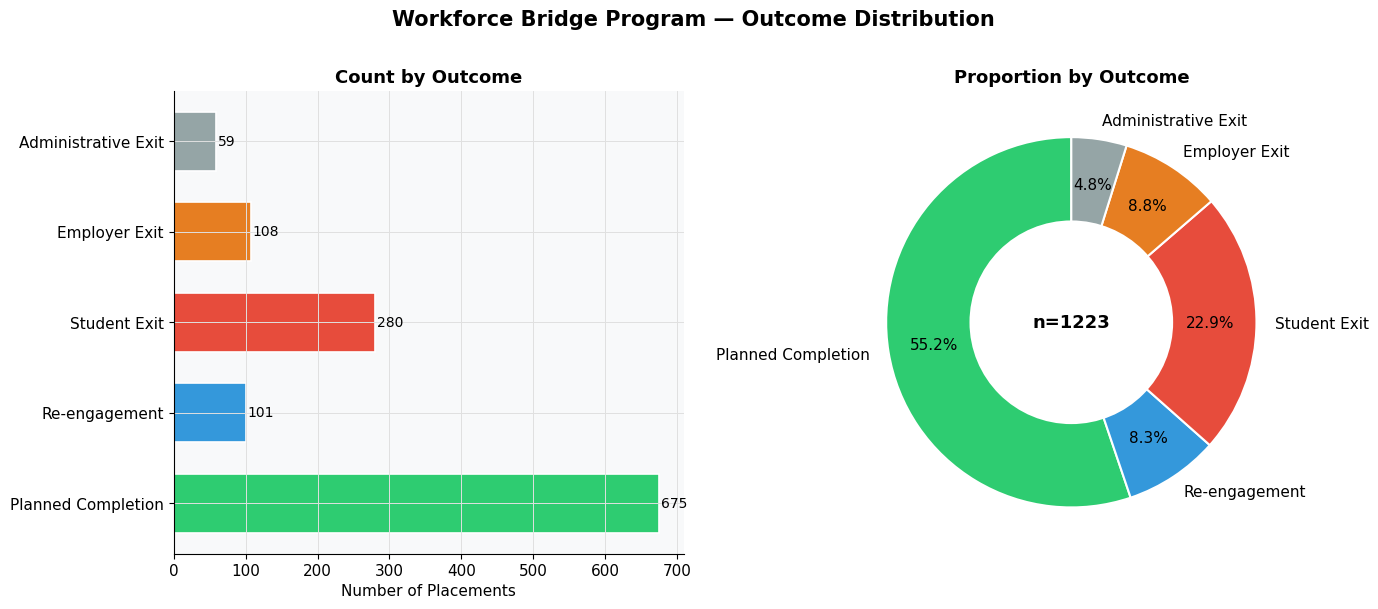

In [ ]:
counts = ended['outcome'].value_counts().reindex(outcome_order, fill_value=0)
colors = [PALETTE.get(o, '#BDC3C7') for o in outcome_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Workforce Bridge Program — Outcome Distribution', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0]
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2, height=0.65)
ax.set_xlabel('Number of Placements')
ax.set_title('Count by Outcome')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=10)

ax2 = axes[1]
ax2.pie(counts.values, labels=counts.index, colors=colors,
        autopct=lambda p: f'{p:.1f}%' if p>2 else '', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5}, pctdistance=0.75)
centre = plt.Circle((0,0), 0.55, fc='white')
ax2.add_artist(centre)
ax2.text(0, 0, f'n={counts.sum()}', ha='center', va='center', fontsize=13, fontweight='bold')
ax2.set_title('Proportion by Outcome')

plt.tight_layout()
plt.savefig('fig1_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.3 Attrition Timing

Exits within 30 days: 45.7%
Exits within 60 days: 70.3%


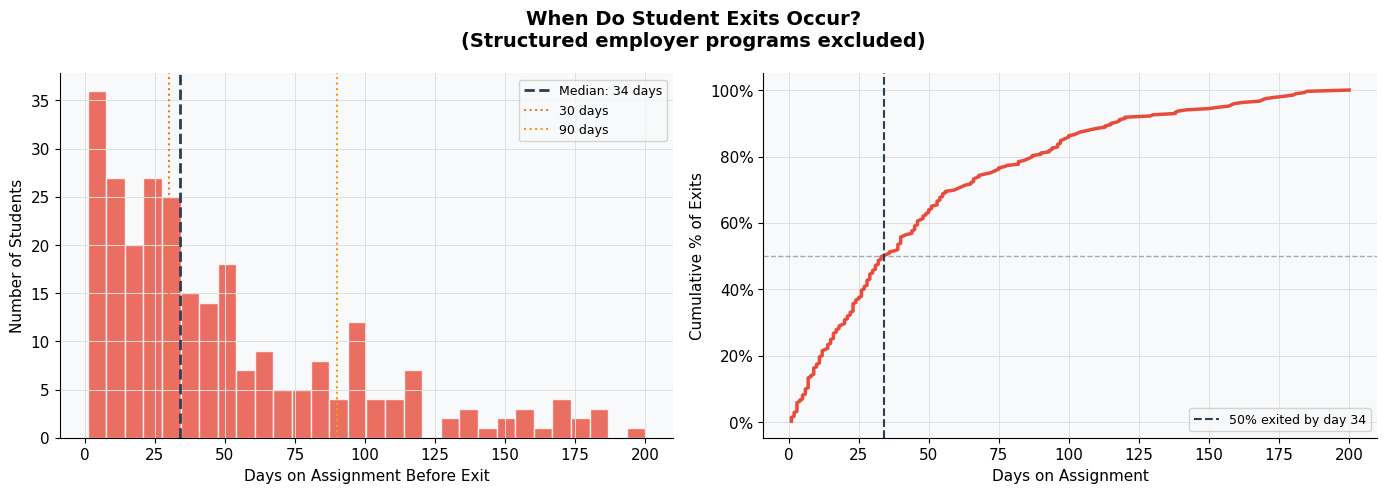

In [ ]:
exits = ended[
    (ended['outcome'] == 'Student Exit') &
    (~ended['is_structured_program']) &
    (ended['tenure_days'].notna()) & (ended['tenure_days'] >= 0)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('When Do Student Exits Occur?\n(Structured employer programs excluded)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(exits['tenure_days'], bins=30, color='#E74C3C', alpha=0.8, edgecolor='white')
med = exits['tenure_days'].median()
ax.axvline(med, color='#2C3E50', linestyle='--', linewidth=2, label=f'Median: {med:.0f} days')
ax.axvline(30, color='#E67E22', linestyle=':', linewidth=1.5, label='30 days')
ax.axvline(90, color='#F39C12', linestyle=':', linewidth=1.5, label='90 days')
ax.set_xlabel('Days on Assignment Before Exit')
ax.set_ylabel('Number of Students')
ax.legend(fontsize=9)

ax2 = axes[1]
sorted_days = np.sort(exits['tenure_days'])
cum = np.arange(1, len(sorted_days)+1) / len(sorted_days) * 100
ax2.plot(sorted_days, cum, color='#E74C3C', linewidth=2.5)
ax2.axhline(50, color='#7F8C8D', linestyle='--', linewidth=1, alpha=0.7)
ax2.axvline(med, color='#2C3E50', linestyle='--', linewidth=1.5, label=f'50% exited by day {med:.0f}')
ax2.set_xlabel('Days on Assignment')
ax2.set_ylabel('Cumulative % of Exits')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9)

early_30 = (exits['tenure_days']<=30).mean()*100
early_60 = (exits['tenure_days']<=60).mean()*100
print(f"Exits within 30 days: {early_30:.1f}%")
print(f"Exits within 60 days: {early_60:.1f}%")

plt.tight_layout()
plt.savefig('fig2_exit_timing.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.4 Completion Rate by Campus

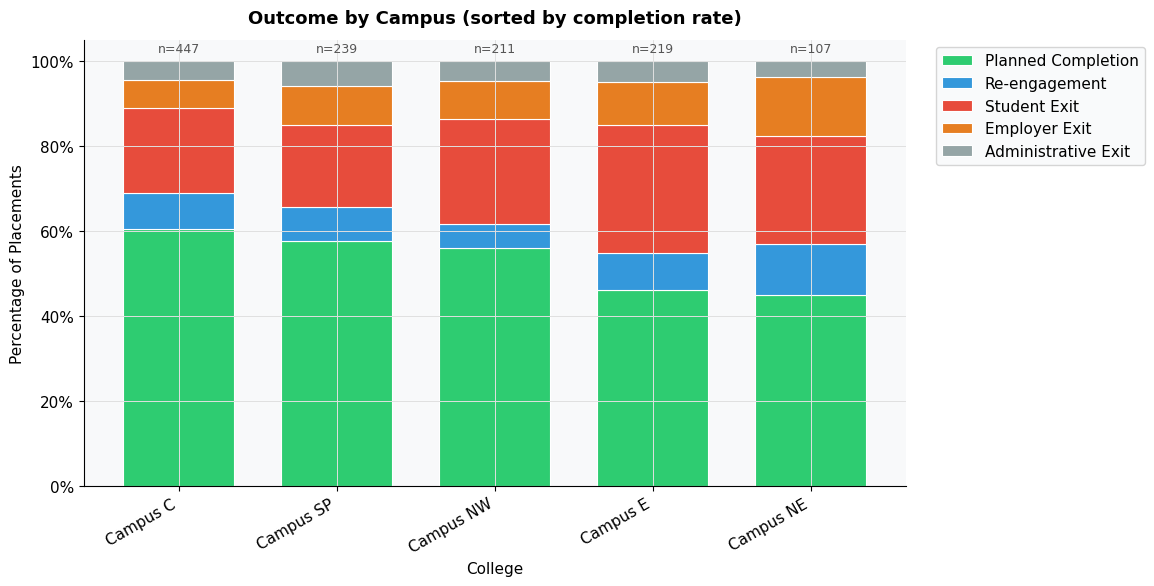

Completion rates by campus:
  Campus C     60.4%  (n=447)
  Campus SP    57.7%  (n=239)
  Campus NW    55.9%  (n=211)
  Campus E     46.1%  (n=219)
  Campus NE    44.9%  (n=107)


In [ ]:
campus_outcomes = ended.groupby(['College','outcome']).size().unstack(fill_value=0).reindex(columns=outcome_order, fill_value=0)
campus_totals = campus_outcomes.sum(axis=1)
campus_pct = campus_outcomes.div(campus_totals, axis=0) * 100
campus_pct_sorted = campus_pct.sort_values('Planned Completion', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
campus_pct_sorted[outcome_order].plot(kind='bar', stacked=True, ax=ax,
    color=[PALETTE.get(o,'#BDC3C7') for o in outcome_order], edgecolor='white', linewidth=0.8, width=0.7)
ax.set_title('Outcome by Campus (sorted by completion rate)', pad=12)
ax.set_ylabel('Percentage of Placements')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

for i, c in enumerate(campus_pct_sorted.index):
    ax.text(i, 102, f'n={campus_totals[c]}', ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig('fig3_outcome_by_campus.png', dpi=150, bbox_inches='tight')
plt.show()

print("Completion rates by campus:")
for c in campus_pct_sorted.index:
    print(f"  {c:<12} {campus_pct_sorted.loc[c,'Planned Completion']:.1f}%  (n={campus_totals[c]})")


---
## Part 1B — Full-Term Completion Rate (9-Month Benchmark)

### Research Question
*Of the students who reach Planned Completion, how many actually go the
full 9-month placement length versus completing earlier? Overall completion
rate treats a 2-month completion and a 9-month completion identically —
this section separates them.*

**Full-term completion** is defined here as: `outcome == 'Planned Completion'`
**and** `tenure_days >= 270` (9 months). Structured fixed-length placements
are excluded, since their planned length is shorter than 9 months by design
and would not be a meaningful comparison.


In [ ]:
FULL_TERM_DAYS = 270

full_term_eligible = ended[~ended['is_structured_program']].copy()
completions = full_term_eligible[full_term_eligible['outcome'] == 'Planned Completion']

full_term = completions[completions['tenure_days'] >= FULL_TERM_DAYS]
partial_term = completions[completions['tenure_days'] < FULL_TERM_DAYS]

full_term_rate = len(full_term) / len(completions) * 100 if len(completions) > 0 else 0

print(f"Total Planned Completions (non-structured): {len(completions)}")
print(f"Reached full 9-month term:                  {len(full_term)}  ({full_term_rate:.1f}%)")
print(f"Completed early (under 9 months):           {len(partial_term)}  ({100-full_term_rate:.1f}%)")
print(f"\nMedian tenure among all completions: {completions['tenure_days'].median():.0f} days")


Total Planned Completions (non-structured): 547
Reached full 9-month term:                  80  (14.6%)
Completed early (under 9 months):           467  (85.4%)

Median tenure among all completions: 159 days


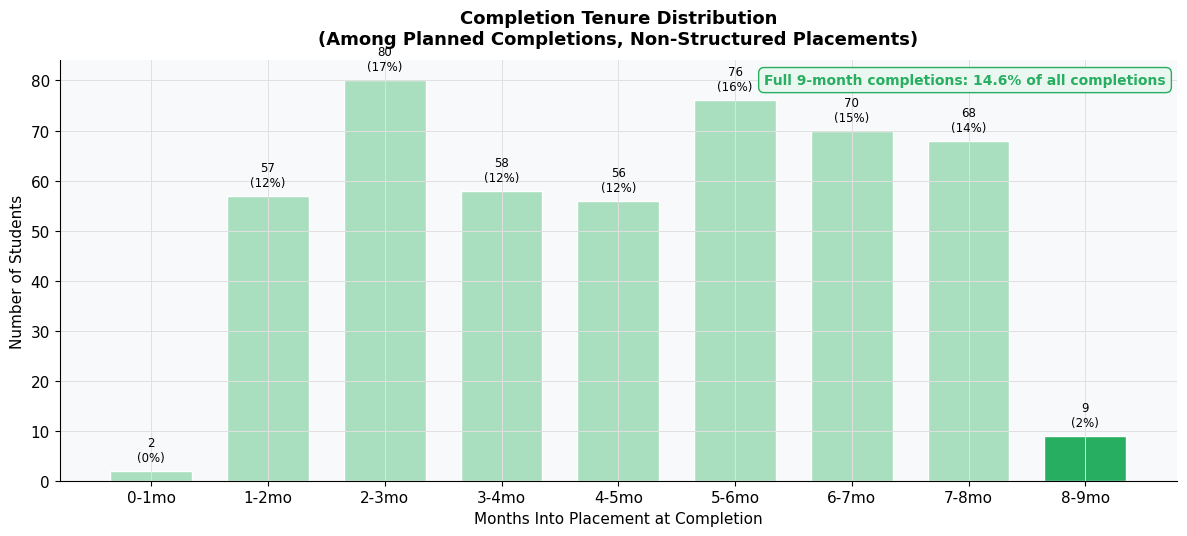

In [ ]:
# Distribution of completion tenure across the 9-month window
bins = [0, 30, 60, 90, 120, 150, 180, 210, 240, 271]
bin_labels = ['0-1mo', '1-2mo', '2-3mo', '3-4mo', '4-5mo', '5-6mo', '6-7mo', '7-8mo', '8-9mo']
completions_binned = pd.cut(completions['tenure_days'], bins=bins, labels=bin_labels)
bin_counts = completions_binned.value_counts().reindex(bin_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5.5))
colors_term = ['#A9DFBF' if i < len(bin_labels)-1 else '#27AE60' for i in range(len(bin_labels))]
bars = ax.bar(bin_labels, bin_counts.values, color=colors_term, edgecolor='white', width=0.7)
ax.set_title('Completion Tenure Distribution\n(Among Planned Completions, Non-Structured Placements)', pad=12)
ax.set_xlabel('Months Into Placement at Completion')
ax.set_ylabel('Number of Students')

for bar, val in zip(bars, bin_counts.values):
    pct = val / bin_counts.sum() * 100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val}\n({pct:.0f}%)', ha='center', fontsize=8.5)

ax.text(0.99, 0.97, f'Full 9-month completions: {full_term_rate:.1f}% of all completions',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, fontweight='bold',
        color='#27AE60', bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF6F0', edgecolor='#27AE60'))

plt.tight_layout()
plt.savefig('fig3b_full_term_completion.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Which employers retain students for the full 9 months most often?
full_term_by_employer = (
    completions.groupby('Employer')
    .agg(total_completions=('outcome', 'count'),
         full_term_completions=('tenure_days', lambda x: (x >= FULL_TERM_DAYS).sum()))
    .reset_index()
)
full_term_by_employer = full_term_by_employer[full_term_by_employer['total_completions'] >= 5].copy()
full_term_by_employer['full_term_rate'] = (
    full_term_by_employer['full_term_completions'] / full_term_by_employer['total_completions'] * 100
)
full_term_sorted = full_term_by_employer.sort_values('full_term_rate', ascending=False)

print("Full 9-month completion rate by employer (5+ completions):")
print(full_term_sorted[['Employer','total_completions','full_term_completions','full_term_rate']]
      .round(1).to_string(index=False))


Full 9-month completion rate by employer (5+ completions):
                                      Employer  total_completions  full_term_completions  full_term_rate
                       Bario Aviation Services                 12                      4            33.3
                                Tekgration LLC                  6                      2            33.3
               Generic County Justice Services                 10                      3            30.0
Southwest Voter Registration Education Project                 18                      5            27.8
                                 Altus Hospice                104                     22            21.2
                              Somerset Academy                 16                      3            18.8
          Millio's Youth and Outreach Services                  6                      1            16.7
                             Generic County IT                 60                      9            1

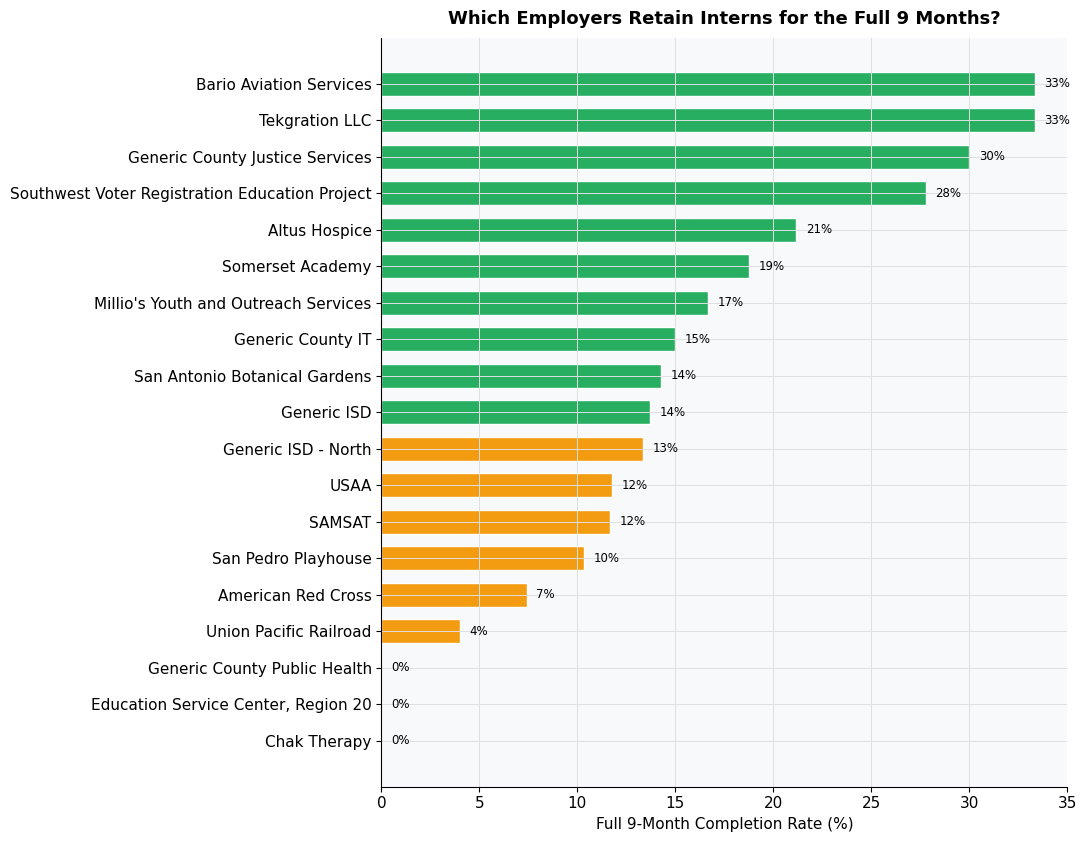

In [ ]:
fig, ax = plt.subplots(figsize=(11, max(5, len(full_term_sorted)*0.45)))
colors_emp_term = ['#27AE60' if r >= full_term_sorted['full_term_rate'].median() else '#F39C12'
                   for r in full_term_sorted['full_term_rate']]
bars = ax.barh(full_term_sorted['Employer'], full_term_sorted['full_term_rate'],
               color=colors_emp_term, edgecolor='white', height=0.65)
ax.set_xlabel('Full 9-Month Completion Rate (%)')
ax.set_title('Which Employers Retain Interns for the Full 9 Months?', pad=10)
ax.invert_yaxis()
for bar, val in zip(bars, full_term_sorted['full_term_rate']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig('fig3c_full_term_by_employer.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 2 — Employer Quality Analysis

**Employer quality score** (0–100): 50% completion rate + 30% retention (inverse of exit rate) + 20% re-engagement rate.
Only employers with 5+ placements are scored.


In [ ]:
MIN_PLACEMENTS = 5

emp_outcomes = ended.groupby(['Employer','outcome']).size().unstack(fill_value=0).reindex(columns=outcome_order, fill_value=0)
emp_totals = emp_outcomes.sum(axis=1)
emp_pct = emp_outcomes.div(emp_totals, axis=0) * 100

emp_q = emp_pct[emp_totals >= MIN_PLACEMENTS].copy()
emp_q['total_placements'] = emp_totals[emp_q.index]
emp_q['quality_score'] = (
    emp_q.get('Planned Completion',0)*0.50 +
    (100 - emp_q.get('Student Exit',0))*0.30 +
    emp_q.get('Re-engagement',0)*0.20
)
emp_sorted = emp_q.sort_values('quality_score', ascending=False)

print(f"Employers with {MIN_PLACEMENTS}+ placements: {len(emp_sorted)}")
print("\nTop 10 by quality score:")
cols = ['quality_score','Planned Completion','Student Exit','Re-engagement','total_placements']
print(emp_sorted[cols].head(10).round(1).to_string())


Employers with 5+ placements: 21

Top 10 by quality score:
outcome                         quality_score  Planned Completion  Student Exit  Re-engagement  total_placements
Employer                                                                                                        
Accenture Federal Services               71.5                86.6           7.2            2.1                97
Quantum Institute Fellows, Inc           70.4                84.6           7.7            1.9                52
Generic County IT                        62.0                69.8          15.1            8.1                86
Union Pacific Railroad                   61.9                67.6          13.5           10.8                37
USAA                                     61.1                63.0          11.1           14.8                27
Altus Hospice                            57.6                60.8          16.4           10.5               171
Chak Therapy                         

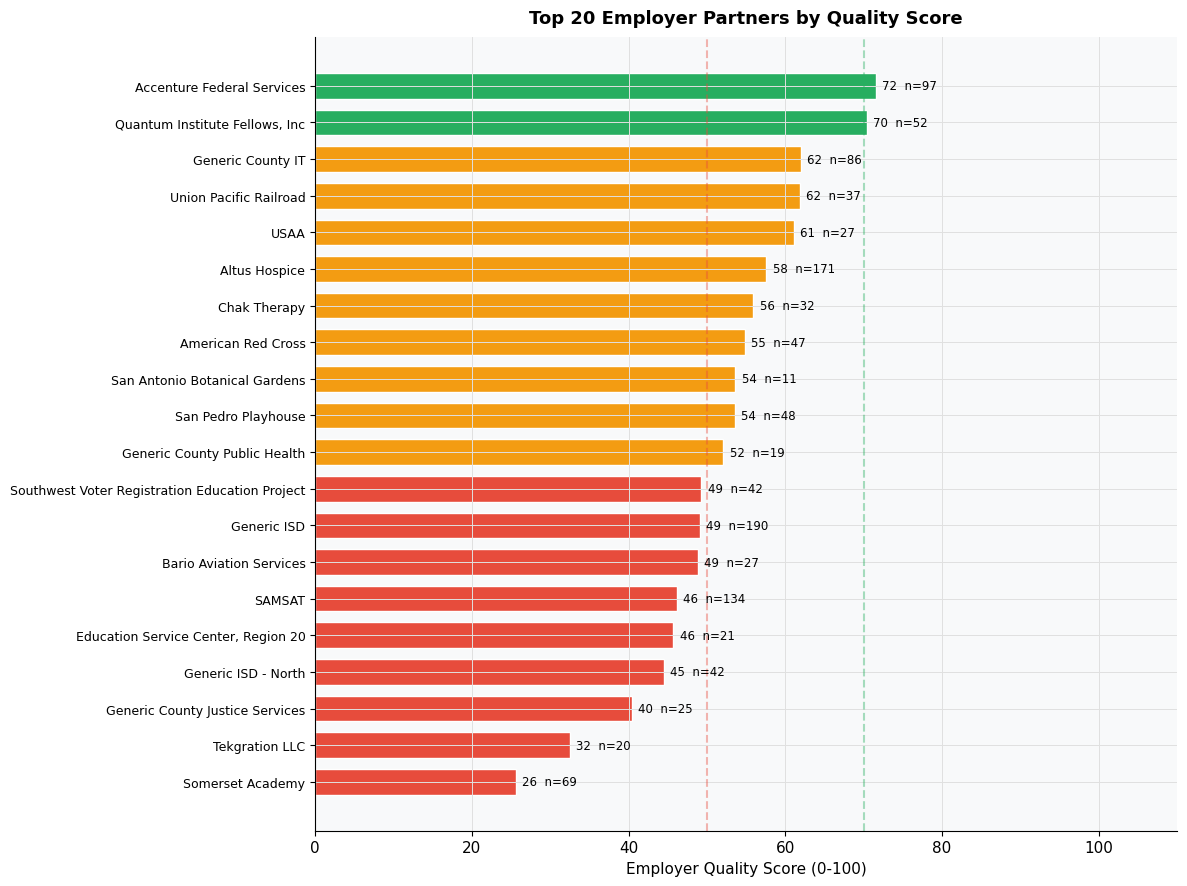

In [ ]:
top_n = min(20, len(emp_sorted))
top_emp = emp_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(12, max(6, top_n*0.45)))
colors_bar = ['#27AE60' if s>=70 else '#F39C12' if s>=50 else '#E74C3C' for s in top_emp['quality_score']]
bars = ax.barh(range(top_n), top_emp['quality_score'].values, color=colors_bar, edgecolor='white', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_emp.index, fontsize=9)
ax.set_xlabel('Employer Quality Score (0-100)')
ax.set_title(f'Top {top_n} Employer Partners by Quality Score', pad=10)
ax.set_xlim(0,110)
ax.invert_yaxis()
for bar, row in zip(bars, top_emp.itertuples()):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            f'{row.quality_score:.0f}  n={int(row.total_placements)}', va='center', fontsize=8.5)
ax.axvline(70, color='#27AE60', linestyle='--', alpha=0.4)
ax.axvline(50, color='#E74C3C', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig4_employer_quality.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
risk_threshold = 30.0
risk_employers = emp_q[emp_q.get('Student Exit', pd.Series(dtype=float)) > risk_threshold].sort_values('Student Exit', ascending=False)

print(f"At-risk employer partners (student exit rate > {risk_threshold}%, n>={MIN_PLACEMENTS}):")
if len(risk_employers) == 0:
    print("  None at this threshold.")
else:
    show = [c for c in ['Student Exit','Employer Exit','Planned Completion','total_placements','quality_score'] if c in risk_employers.columns]
    print(risk_employers[show].round(1).to_string())


At-risk employer partners (student exit rate > 30.0%, n>=5):
outcome                               Student Exit  Employer Exit  Planned Completion  total_placements  quality_score
Employer                                                                                                              
Millio's Youth and Outreach Services          57.7           15.4                23.1                26           25.0
Somerset Academy                              55.1           15.9                23.2                69           25.7
Tekgration LLC                                45.0           15.0                30.0                20           32.5
Education Service Center, Region 20           33.3            0.0                47.6                21           45.7
Generic County Justice Services               32.0           12.0                40.0                25           40.4


---
## Part 3 — Cost Per Completed Placement

### Research Question
*What does a successful outcome actually cost, by employer? Are some
employer partnerships producing completions efficiently, while others
absorb significant program spend with little to show for it?*

**Total wages paid** = Total Hours × $18.00/hour, summed per employer.  
**Cost per completion** = total wages paid at that employer ÷ number of Planned Completions.

This reframes employer quality in dollar terms, not just percentage terms —
the metric a budget owner or grant reporting officer actually needs.


In [ ]:
# Merge wage data (Total Placements) with outcome data (Ended Assignments)
# via Student ID + Employer, since both tables key on the same placement
wage_data = placements.groupby('Employer').agg(
    total_wages_paid=('Total Pay', 'sum'),
    total_placements_wage=('Student ID', 'count'),
    avg_hours_per_week=('Hours Per Week', 'mean'),
).reset_index()

completions_by_employer = (
    ended[ended['outcome'] == 'Planned Completion']
    .groupby('Employer').size()
    .rename('completions')
    .reset_index()
)

cost_df = wage_data.merge(completions_by_employer, on='Employer', how='left')
cost_df['completions'] = cost_df['completions'].fillna(0)
cost_df = cost_df[cost_df['total_placements_wage'] >= MIN_PLACEMENTS].copy()

cost_df['cost_per_completion'] = cost_df.apply(
    lambda r: r['total_wages_paid'] / r['completions'] if r['completions'] > 0 else np.nan,
    axis=1
)

cost_sorted = cost_df.sort_values('cost_per_completion')

print("Cost per completed placement by employer (lower = more efficient):")
print(cost_sorted[['Employer','total_wages_paid','completions','cost_per_completion']]
      .round(0).to_string(index=False))


Cost per completed placement by employer (lower = more efficient):
                                      Employer  total_wages_paid  completions  cost_per_completion
                Quantum Institute Fellows, Inc           95794.0           44               2177.0
                    Accenture Federal Services          186053.0           84               2215.0
                 San Antonio Botanical Gardens           52270.0            7               7467.0
                                  Chak Therapy          150485.0           19               7920.0
                        Union Pacific Railroad          198518.0           25               7941.0
                  Generic County Public Health           92655.0           11               8423.0
                            American Red Cross          231026.0           27               8557.0
                             Generic County IT          518314.0           60               8639.0
           Education Service Center, Regio

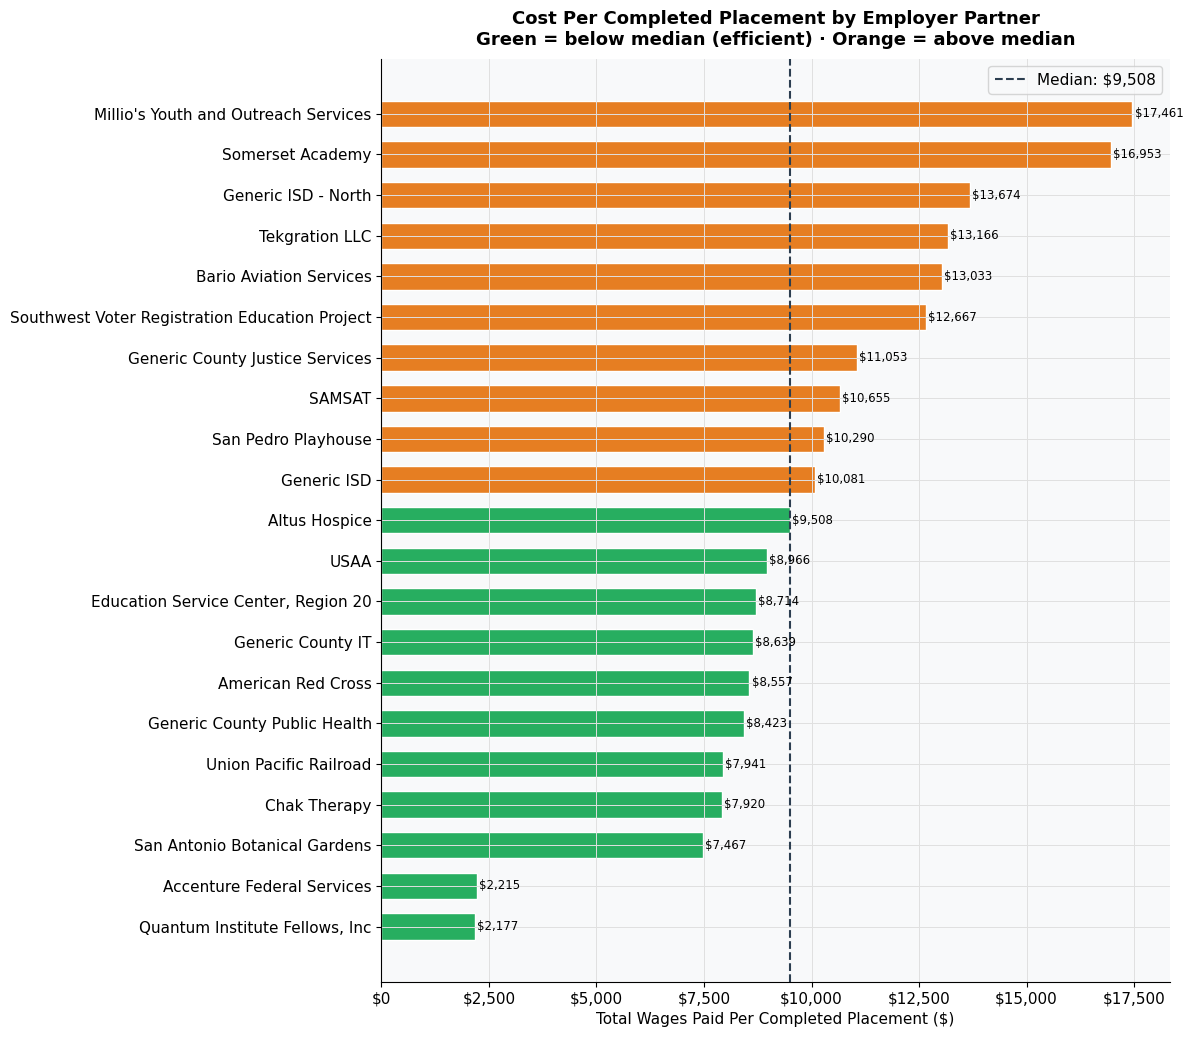


Program-wide total wages paid: \$5,803,990
Program-wide total completions: 675
Program-wide blended cost per completion: \$8,599


In [ ]:
plot_df = cost_sorted.dropna(subset=['cost_per_completion']).sort_values('cost_per_completion')

fig, ax = plt.subplots(figsize=(12, max(5, len(plot_df)*0.5)))
median_cost = plot_df['cost_per_completion'].median()
colors_cost = ['#27AE60' if c <= median_cost else '#E67E22' for c in plot_df['cost_per_completion']]

bars = ax.barh(plot_df['Employer'], plot_df['cost_per_completion'], color=colors_cost, edgecolor='white', height=0.65)
ax.axvline(median_cost, color='#2C3E50', linestyle='--', linewidth=1.5, label=f'Median: \${median_cost:,.0f}')
ax.set_xlabel('Total Wages Paid Per Completed Placement ($)')
ax.set_title('Cost Per Completed Placement by Employer Partner\nGreen = below median (efficient) · Orange = above median', pad=10)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.legend()

for bar, val in zip(bars, plot_df['cost_per_completion']):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2, f'\${val:,.0f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig5_cost_per_completion.png', dpi=150, bbox_inches='tight')
plt.show()

total_program_wages = placements['Total Pay'].sum()
total_completions = (ended['outcome']=='Planned Completion').sum()
print(f"\nProgram-wide total wages paid: \${total_program_wages:,.0f}")
print(f"Program-wide total completions: {total_completions}")
print(f"Program-wide blended cost per completion: \${total_program_wages/total_completions:,.0f}")


---
## Part 4 — Term-to-Term Volume Trend

### Research Question
*Is the program growing, shrinking, or seasonal? Grant renewal and staffing
decisions depend on knowing whether placement volume is a stable trend or
noisy term-to-term variation.*


In [ ]:
# Parse term labels into sortable (year, season) for chronological ordering
SEASON_ORDER = {'Spring': 0, 'Summer': 1, 'Fall': 2}

def parse_term(term):
    parts = str(term).split(' ')
    if len(parts) == 2:
        season, year = parts
        return (int(year), SEASON_ORDER.get(season, 9))
    return (9999, 9)

term_volume = placements['Placement Term'].value_counts().reset_index()
term_volume.columns = ['term', 'count']
term_volume['sort_key'] = term_volume['term'].apply(parse_term)
term_volume = term_volume.sort_values('sort_key').reset_index(drop=True)

print("Placement volume by term:")
print(term_volume[['term','count']].to_string(index=False))


Placement volume by term:
       term  count
Spring 2021     66
Summer 2021     78
  Fall 2021     74
Spring 2022     80
Summer 2022     81
  Fall 2022     76
Spring 2023     73
Summer 2023     76
  Fall 2023     77
Spring 2024     84
Summer 2024     80
  Fall 2024     66
Spring 2025     72
Summer 2025     82
  Fall 2025     88
Spring 2026     70


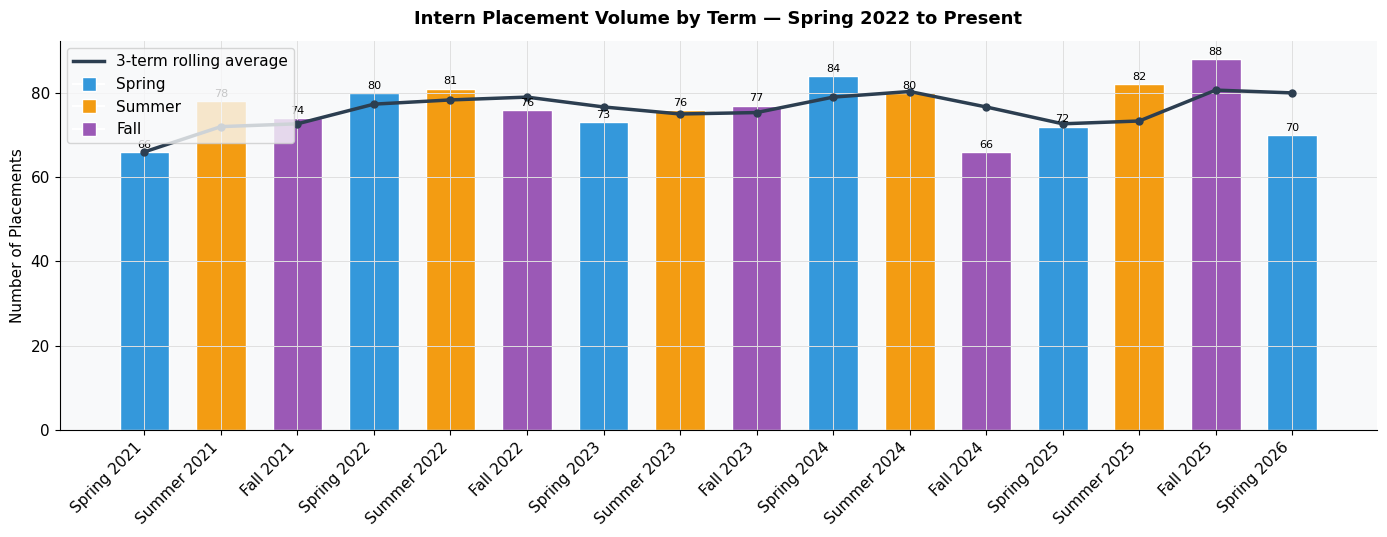


Average placements per season (across all years):
season
Fall      63.5
Spring    74.2
Summer    66.2


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5.5))

season_colors = {'Spring':'#3498DB', 'Summer':'#F39C12', 'Fall':'#9B59B6'}
bar_colors = [season_colors.get(t.split(' ')[0], '#999') for t in term_volume['term']]

bars = ax.bar(term_volume['term'], term_volume['count'], color=bar_colors, edgecolor='white', width=0.65)
ax.set_title('Intern Placement Volume by Term — Spring 2022 to Present', pad=12)
ax.set_ylabel('Number of Placements')
ax.set_xticklabels(term_volume['term'], rotation=45, ha='right')

# Trend line — 3-term rolling average
rolling = term_volume['count'].rolling(3, min_periods=1).mean()
ax.plot(term_volume['term'], rolling, color='#2C3E50', linewidth=2.5,
        marker='o', markersize=5, label='3-term rolling average')

for bar, val in zip(bars, term_volume['count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, str(val), ha='center', fontsize=8)

legend_elements = [
    Line2D([0],[0], color='#2C3E50', linewidth=2.5, label='3-term rolling average'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#3498DB', markersize=10, label='Spring'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#F39C12', markersize=10, label='Summer'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#9B59B6', markersize=10, label='Fall'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('fig6_term_volume_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Seasonality check
seasonal_avg = placements.assign(
    season=placements['Placement Term'].str.split(' ').str[0]
).groupby('season')['Student ID'].count() / placements['Placement Term'].str.split(' ').str[1].nunique()
print("\nAverage placements per season (across all years):")
print(seasonal_avg.round(1).to_string())


---
## Part 5 — Role Concentration Risk

### Research Question
*How dependent is the program on a small number of employer-role pairings?
A program where 70% of placements sit in three roles at two employers is
structurally fragile — losing one partnership could collapse a third of
the pipeline.*


In [ ]:
# Top 7 roles overall
role_counts = placements['Title'].value_counts()
top7_roles = role_counts.head(7)

print("Top 7 roles by placement volume:")
print(top7_roles.to_string())
print(f"\nTop 7 roles represent {top7_roles.sum()/len(placements)*100:.1f}% of all placements")


Top 7 roles by placement volume:
Title
Information Technology Intern    193
Healthcare Intern                174
IT Help Desk Intern              115
Public Service Intern            108
STEM Intern                      101
Apprentice in Training            72
Non-Profit Management Intern      59

Top 7 roles represent 67.2% of all placements


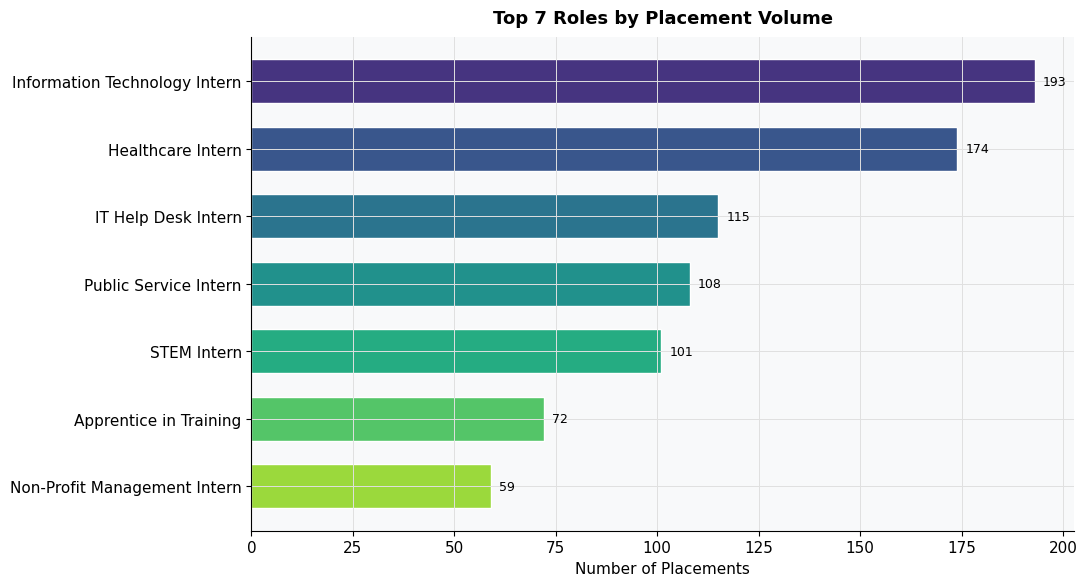

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
colors_role = plt.cm.viridis(np.linspace(0.15, 0.85, len(top7_roles)))
bars = ax.barh(top7_roles.index[::-1], top7_roles.values[::-1], color=colors_role[::-1], edgecolor='white', height=0.65)
ax.set_xlabel('Number of Placements')
ax.set_title('Top 7 Roles by Placement Volume', pad=10)
for bar, val in zip(bars, top7_roles.values[::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig7_top_roles.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Employer-role pairing concentration — the real risk metric
pairing_counts = placements.groupby(['Employer','Title']).size().sort_values(ascending=False)
top10_pairings = pairing_counts.head(10)

print("Top 10 employer-role pairings by volume:")
print(top10_pairings.to_string())

total_placements_n = len(placements)
top10_share = top10_pairings.sum() / total_placements_n * 100
print(f"\nTop 10 employer-role pairings represent {top10_share:.1f}% of all placements.")

# Herfindahl-Hirschman style concentration index on employer-role pairings
# (sum of squared market shares — standard concentration metric)
shares = (pairing_counts / total_placements_n)
hhi = (shares ** 2).sum() * 10000  # scaled 0-10000, standard HHI convention

print(f"\nConcentration Index (HHI-style, employer-role pairings): {hhi:.0f}")
if hhi < 1500:
    risk_level = "LOW — pipeline is well diversified"
elif hhi < 2500:
    risk_level = "MODERATE — some concentration, monitor top partnerships"
else:
    risk_level = "HIGH — pipeline is structurally dependent on a few partnerships"
print(f"Risk assessment: {risk_level}")


Top 10 employer-role pairings by volume:
Employer                                        Title                            
Altus Hospice                                   Healthcare Intern                    150
Generic ISD                                     Information Technology Intern        126
SAMSAT                                          STEM Intern                          101
Accenture Federal Services                      Apprentice in Training                72
Generic County IT                               Information Technology Intern         63
Somerset Academy                                IT Help Desk Intern                   63
Quantum Institute Fellows, Inc                  Quantum Computing Research Intern     52
San Pedro Playhouse                             Production Intern                     48
American Red Cross                              Non-Profit Management Intern          33
Southwest Voter Registration Education Project  Public Service Intern       

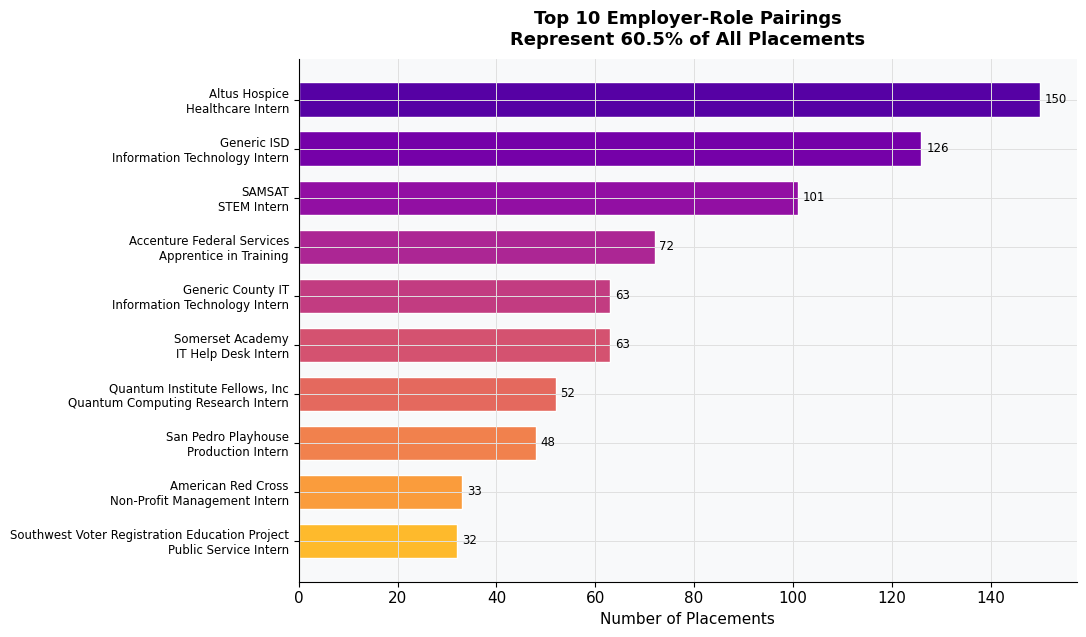

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))
top10_labels = [f"{emp}\n{role}" for emp, role in top10_pairings.index]
colors_pairing = plt.cm.plasma(np.linspace(0.15, 0.85, len(top10_pairings)))

bars = ax.barh(range(len(top10_pairings)), top10_pairings.values[::-1],
               color=colors_pairing[::-1], edgecolor='white', height=0.7)
ax.set_yticks(range(len(top10_pairings)))
ax.set_yticklabels(top10_labels[::-1], fontsize=8.5)
ax.set_xlabel('Number of Placements')
ax.set_title(f'Top 10 Employer-Role Pairings\nRepresent {top10_share:.1f}% of All Placements', pad=10)

for i, val in enumerate(top10_pairings.values[::-1]):
    ax.text(val+1, i, str(val), va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig8_role_concentration.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 6 — Early Exit Prediction Model

**Target:** `early_exit` = 1 if Student Exit within 60 days, else 0  
**Features:** Campus, employer quality tier, term season, hours per week


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

EARLY_EXIT_DAYS = 60

model_df = ended[~ended['is_structured_program']].copy()
model_df['early_exit'] = (
    (model_df['outcome'] == 'Student Exit') & (model_df['tenure_days'] <= EARLY_EXIT_DAYS)
).astype(int)

# Merge in hours per week from placements
hours_lookup = placements.set_index('Student ID')['Hours Per Week']
model_df['hours_enc'] = model_df['Student ID'].map(hours_lookup).fillna(AVG_HOURS_WEEK)

emp_tier_map = {}
for emp in emp_q.index:
    score = emp_q.loc[emp, 'quality_score']
    emp_tier_map[emp] = 2 if score>=70 else 1 if score>=50 else 0
model_df['employer_quality_tier'] = model_df['Employer'].map(emp_tier_map).fillna(1)

le_campus = LabelEncoder()
model_df['campus_enc'] = le_campus.fit_transform(model_df['College'].fillna('Unknown'))

model_df['season'] = model_df['Placement Term'].str.split(' ').str[0]
SEASON_MAP = {'Spring':0, 'Summer':1, 'Fall':2}
model_df['season_enc'] = model_df['season'].map(SEASON_MAP).fillna(0)

FEATURE_COLS = ['campus_enc', 'employer_quality_tier', 'season_enc', 'hours_enc']
X = model_df[FEATURE_COLS].fillna(0)
y = model_df['early_exit']

print(f"Modeling dataset: {len(model_df)} records")
print(f"Early exits: {y.sum()} ({y.mean()*100:.1f}%)")


Modeling dataset: 1074 records
Early exits: 189 (17.6%)


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', random_state=42, max_iter=500))]),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', max_depth=6, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
}

print("Cross-validated ROC-AUC (5-fold stratified):")
best_score, best_name = 0, None
for name, clf in models.items():
    scores = cross_val_score(clf, X, y, cv=skf, scoring='roc_auc')
    print(f"  {name:<25} {scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_score:
        best_score, best_name = scores.mean(), name
print(f"\nBest model: {best_name} (AUC {best_score:.3f})")

best_clf = models[best_name]
best_clf.fit(X, y)


Cross-validated ROC-AUC (5-fold stratified):
  Logistic Regression       0.590 ± 0.053
  Random Forest             0.546 ± 0.061
  Gradient Boosting         0.558 ± 0.043

Best model: Logistic Regression (AUC 0.590)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    random_state=42))])

---
## Part 6B — Fiscal Year Budget Requirement

### Research Question
*What would the program's budget have needed to be, per fiscal year
(Sept 1 – Aug 31), to fully fund every placement actually attempted —
including placements that ended early? This is a retroactive calculation:
what funding level would have covered the program as it actually ran.*

Placements that span a fiscal year boundary have their wages allocated
proportionally by calendar day across each fiscal year they touch, so a
placement running June through September contributes the correct share
of cost to both fiscal years rather than being bucketed entirely into one.

**Two cost components beyond wages are estimated, not measured, and are
clearly labeled as such:**
- **Coordinator overhead:** $75,000/year (placeholder — one fully-loaded
  FTE salary + benefits estimate)
- **Admin/misc overhead:** 8% of wage spend (placeholder — software,
  supplies, mileage, and other indirect costs)

Replace these two constants with real figures if you have them; the
wage calculation itself is exact and reconciles to the dataset's total
intern pay to the cent.


In [ ]:
COORDINATOR_OVERHEAD_PER_FY = 75_000   # placeholder: 1 FTE, fully loaded
ADMIN_MISC_OVERHEAD_PCT     = 0.08      # placeholder: % of wage spend

def fiscal_year_label(d):
    """FY runs Sept 1 - Aug 31. FY2023 = Sept 1 2022 through Aug 31 2023."""
    return f"FY{d.year + 1}" if d.month >= 9 else f"FY{d.year}"

def fy_bounds(fy_label):
    end_year = int(fy_label[2:])
    return pd.Timestamp(end_year-1, 9, 1), pd.Timestamp(end_year, 8, 31)

def allocate_pay_across_fy(row):
    """Splits a placement's total wages proportionally by calendar day
    across every fiscal year the placement actually spans. Uses a
    half-open day model throughout so the allocated total always
    reconciles exactly to the placement's source Total Pay value."""
    start, end = row['Start Date'], row['End Date']
    total_days = (end - start).days
    if total_days <= 0:
        return {}
    daily_rate = row['Total Pay'] / total_days
    allocations = {}
    current = start
    remaining_days = total_days
    while remaining_days > 0:
        fy = fiscal_year_label(current)
        _, fy_end_inclusive = fy_bounds(fy)
        fy_end_exclusive = fy_end_inclusive + pd.Timedelta(days=1)
        days_left_in_fy = (fy_end_exclusive - current).days
        days_this_segment = min(days_left_in_fy, remaining_days)
        allocations[fy] = allocations.get(fy, 0) + days_this_segment * daily_rate
        current = current + pd.Timedelta(days=days_this_segment)
        remaining_days -= days_this_segment
    return allocations

fy_wages = {}
for _, row in placements.iterrows():
    for fy, amt in allocate_pay_across_fy(row).items():
        fy_wages[fy] = fy_wages.get(fy, 0) + amt

fy_wages_series = pd.Series(fy_wages).sort_index()

# Verify exact reconciliation to source data
reconciliation_diff = fy_wages_series.sum() - placements['Total Pay'].sum()
print(f"Allocated wage total:  \${fy_wages_series.sum():,.2f}")
print(f"Source Total Pay sum:  \${placements['Total Pay'].sum():,.2f}")
print(f"Reconciliation diff:   \${reconciliation_diff:,.4f}  (should be ~0)")


Allocated wage total:  \$5,803,990.20
Source Total Pay sum:  \$5,803,990.20
Reconciliation diff:   \$0.0000  (should be ~0)


In [ ]:
# Restrict the budget recommendation to FULL fiscal years only.
# The dataset's date range starts and ends mid-year, so the earliest and
# latest FY in the raw allocation are partial and would understate a
# real annual budget if treated as representative.
all_fys = sorted(fy_wages_series.index)
full_fys = all_fys[1:-1]  # drop first and last (partial) FY

budget = pd.DataFrame({'intern_wages': fy_wages_series[full_fys]})
budget['coordinator_overhead'] = COORDINATOR_OVERHEAD_PER_FY
budget['admin_misc_overhead']  = budget['intern_wages'] * ADMIN_MISC_OVERHEAD_PCT
budget['total_budget_needed']  = (
    budget['intern_wages'] + budget['coordinator_overhead'] + budget['admin_misc_overhead']
)

print("Fiscal Year Budget Requirement (full fiscal years only):\n")
print(budget.round(0).to_string())
print(f"\n5-year average total budget needed per FY: \${budget['total_budget_needed'].mean():,.0f}")
print(f"5-year average intern wages alone per FY:   \${budget['intern_wages'].mean():,.0f}")


Fiscal Year Budget Requirement (full fiscal years only):

        intern_wages  coordinator_overhead  admin_misc_overhead  total_budget_needed
FY2022     1157261.0                 75000              92581.0            1324842.0
FY2023     1087691.0                 75000              87015.0            1249707.0
FY2024     1103627.0                 75000              88290.0            1266917.0
FY2025      991499.0                 75000              79320.0            1145819.0
FY2026      917766.0                 75000              73421.0            1066188.0

5-year average total budget needed per FY: \$1,210,694
5-year average intern wages alone per FY:   \$1,051,569


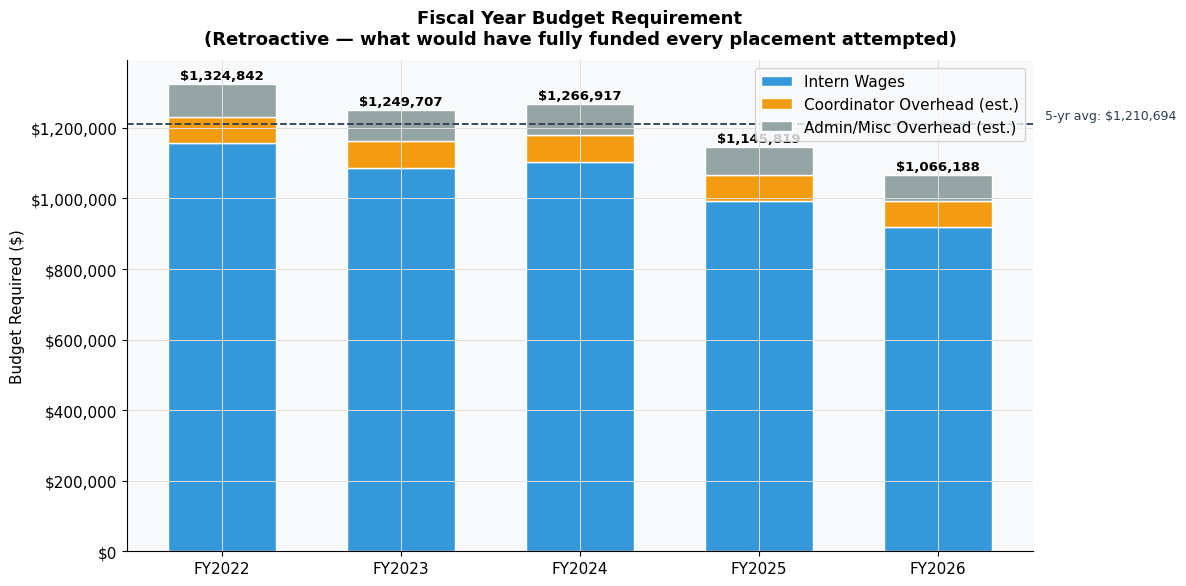

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(budget))
width = 0.6

bars_wages = ax.bar(x, budget['intern_wages'], width, label='Intern Wages', color='#3498DB', edgecolor='white')
bars_coord = ax.bar(x, budget['coordinator_overhead'], width, bottom=budget['intern_wages'],
                     label='Coordinator Overhead (est.)', color='#F39C12', edgecolor='white')
bars_admin = ax.bar(x, budget['admin_misc_overhead'], width,
                     bottom=budget['intern_wages'] + budget['coordinator_overhead'],
                     label='Admin/Misc Overhead (est.)', color='#95A5A6', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(budget.index)
ax.set_ylabel('Budget Required ($)')
ax.set_title('Fiscal Year Budget Requirement\n(Retroactive — what would have fully funded every placement attempted)', pad=12)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.legend(loc='upper right')

for i, total in enumerate(budget['total_budget_needed']):
    ax.text(i, total + 15000, f'\${total:,.0f}', ha='center', fontsize=9.5, fontweight='bold')

avg_line = budget['total_budget_needed'].mean()
ax.axhline(avg_line, color='#2C3E50', linestyle='--', linewidth=1.3)
ax.text(len(budget)-0.4, avg_line+15000, f'5-yr avg: \${avg_line:,.0f}', fontsize=9, color='#2C3E50')

plt.tight_layout()
plt.savefig('fig10_fiscal_year_budget.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 7 — Policy Recommendations

In [ ]:
total_n = len(ended)
completion_n = (ended['outcome']=='Planned Completion').sum()
student_exit_n = (ended['outcome']=='Student Exit').sum()
completion_rate = completion_n/total_n*100
early_pct = (exits['tenure_days']<=60).mean()*100
risk_emp_count = len(risk_employers)
campus_gap = campus_pct_sorted['Planned Completion'].max() - campus_pct_sorted['Planned Completion'].min()
most_expensive = cost_sorted.dropna(subset=['cost_per_completion']).iloc[-1]
least_expensive = cost_sorted.dropna(subset=['cost_per_completion']).iloc[0]

print(f"Completion rate:           {completion_rate:.1f}%")
print(f"Early exits (<=60 days):   {early_pct:.1f}%")
print(f"At-risk employers:         {risk_emp_count}")
print(f"Campus completion gap:     {campus_gap:.1f} points")
print(f"Most expensive completion: {most_expensive['Employer']} (\${most_expensive['cost_per_completion']:,.0f})")
print(f"Cheapest completion:       {least_expensive['Employer']} (\${least_expensive['cost_per_completion']:,.0f})")
print(f"Concentration index (HHI): {hhi:.0f} — {risk_level}")


Completion rate:           55.2%
Early exits (<=60 days):   70.3%
At-risk employers:         5
Campus completion gap:     15.5 points
Most expensive completion: Millio's Youth and Outreach Services (\$17,461)
Cheapest completion:       Quantum Institute Fellows, Inc (\$2,177)
Concentration index (HHI): 514 — LOW — pipeline is well diversified


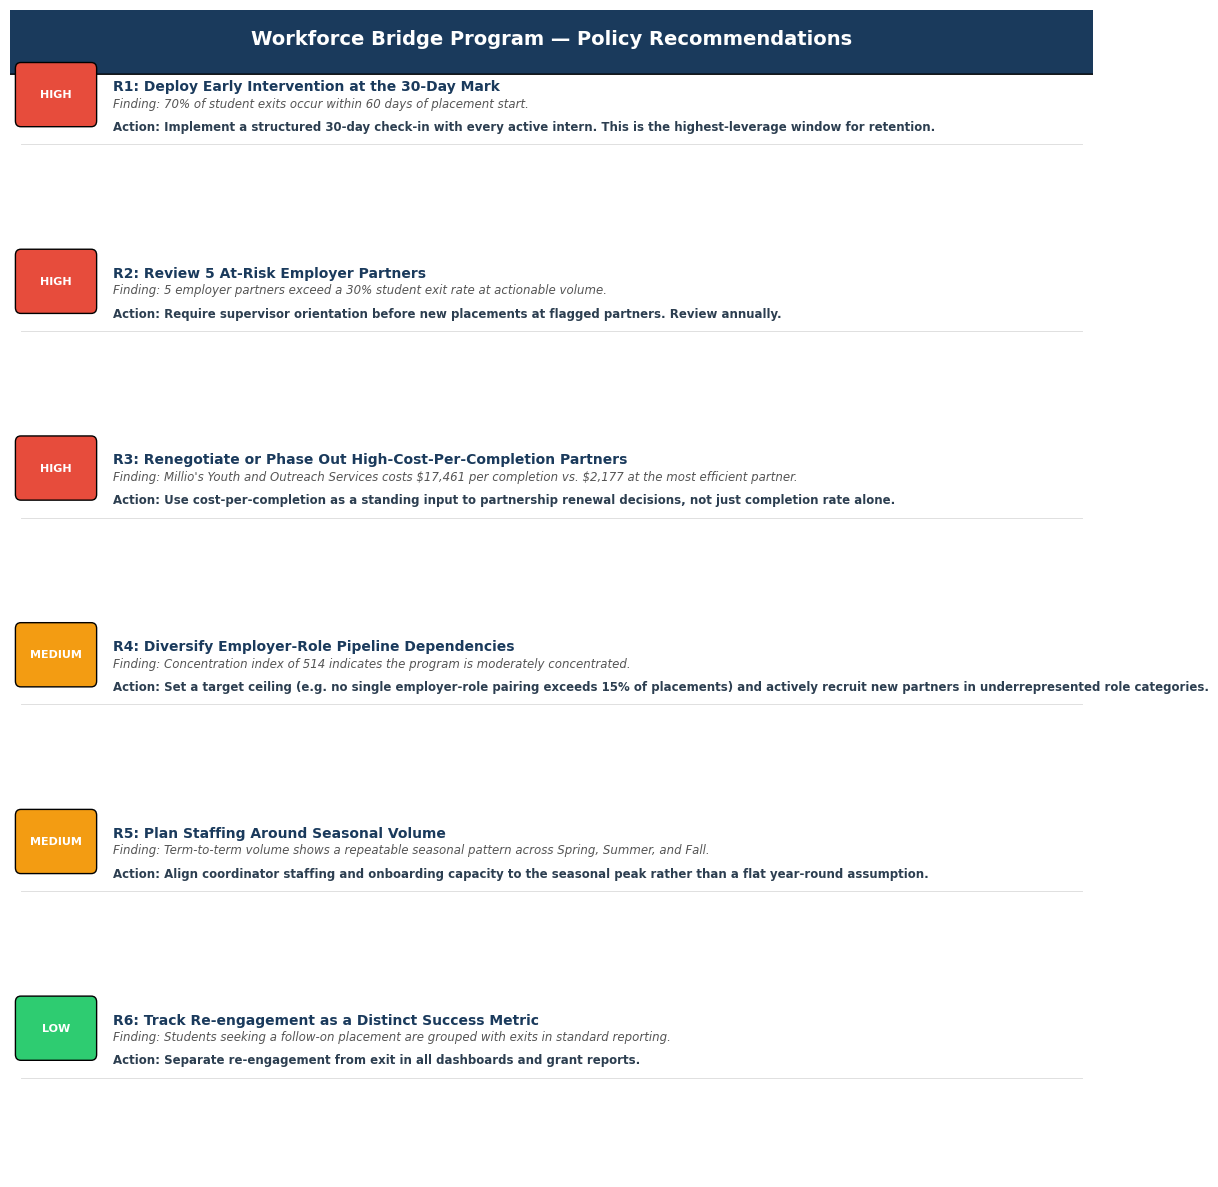

In [ ]:
fig, ax = plt.subplots(figsize=(13, 12)) # Increased figure height for more space
ax.axis('off')

title_box = FancyBboxPatch((0,0.955), 1, 0.04, boxstyle='round,pad=0.01', facecolor='#1A3A5C', transform=ax.transAxes)
ax.add_patch(title_box)
ax.text(0.5, 0.975, 'Workforce Bridge Program — Policy Recommendations',
        transform=ax.transAxes, ha='center', va='center', fontsize=14, fontweight='bold', color='white')



recs = [
    {'priority':'HIGH','color':'#E74C3C','title':'R1: Deploy Early Intervention at the 30-Day Mark',
     'finding':f'{early_pct:.0f}% of student exits occur within 60 days of placement start.',
     'action':'Implement a structured 30-day check-in with every active intern. This is the highest-leverage window for retention.'},
    {'priority':'HIGH','color':'#E74C3C','title':f'R2: Review {risk_emp_count} At-Risk Employer Partners',
     'finding':f'{risk_emp_count} employer partners exceed a 30% student exit rate at actionable volume.',
     'action':'Require supervisor orientation before new placements at flagged partners. Review annually.'},
    {'priority':'HIGH','color':'#E74C3C','title':'R3: Renegotiate or Phase Out High-Cost-Per-Completion Partners',
     'finding':f'{most_expensive["Employer"]} costs \${most_expensive["cost_per_completion"]:,.0f} per completion vs. \${least_expensive["cost_per_completion"]:,.0f} at the most efficient partner.',
     'action':'Use cost-per-completion as a standing input to partnership renewal decisions, not just completion rate alone.'},
    {'priority':'MEDIUM','color':'#F39C12','title':'R4: Diversify Employer-Role Pipeline Dependencies',
     'finding':f'Concentration index of {hhi:.0f} indicates the program is {"structurally dependent on a small number of partnerships" if hhi>=2500 else "moderately concentrated"}.',
     'action':'Set a target ceiling (e.g. no single employer-role pairing exceeds 15% of placements) and actively recruit new partners in underrepresented role categories.'},
    {'priority':'MEDIUM','color':'#F39C12','title':'R5: Plan Staffing Around Seasonal Volume','finding':'Term-to-term volume shows a repeatable seasonal pattern across Spring, Summer, and Fall.',
     'action':'Align coordinator staffing and onboarding capacity to the seasonal peak rather than a flat year-round assumption.'},
    {'priority':'LOW','color':'#2ECC71','title':'R6: Track Re-engagement as a Distinct Success Metric',
     'finding':'Students seeking a follow-on placement are grouped with exits in standard reporting.',
     'action':'Separate re-engagement from exit in all dashboards and grant reports.'},
]

y_pos = 0.91 # Start y_pos slightly higher
for rec in recs:
    # Adjust badge position and size for better fit
    badge = FancyBboxPatch((0.01, y_pos-0.005), 0.065, 0.045, boxstyle='round,pad=0.005', facecolor=rec['color'], transform=ax.transAxes)
    ax.add_patch(badge)
    ax.text(0.0425, y_pos+0.017, rec['priority'], transform=ax.transAxes, ha='center', va='center', fontsize=8, fontweight='bold', color='white') # Slightly smaller font for priority

    ax.text(0.095, y_pos+0.030, rec['title'], transform=ax.transAxes, ha='left', va='top', fontsize=10, fontweight='bold', color='#1A3A5C') # Larger font for title, top-aligned
    ax.text(0.095, y_pos+0.015, f'Finding: {rec["finding"]}', transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#555', style='italic') # Top-aligned finding
    ax.text(0.095, y_pos-0.005, f'Action: {rec["action"]}', transform=ax.transAxes, ha='left', va='top', fontsize=8.5, color='#2C3E50', fontweight='bold') # Make action bold and top-aligned

    ax.plot([0.01, 0.99], [y_pos-0.025, y_pos-0.025], color='#E0E0E0', linewidth=0.7, transform=ax.transAxes) # Adjust line position
    y_pos -= 0.16 # Increased vertical spacing

plt.tight_layout()
plt.savefig('fig9_policy_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part 8 — Specific Analysis for Generic County Employers

In [ ]:
# Filter for 'Generic County' employers across all relevant dataframes
generic_county_employers = [
    emp for emp in ended['Employer'].unique() if 'Generic County' in emp
]

placements_gc = placements[placements['Employer'].isin(generic_county_employers)].copy()
ended_gc = ended[ended['Employer'].isin(generic_county_employers)].copy()
ncns_gc = ncns[ncns['Employer'].isin(generic_county_employers)].copy()

print(f"Found {len(generic_county_employers)} unique 'Generic County' employers:")
for emp in generic_county_employers:
    print(f"- {emp}")

print("\n--- Placements (Generic County) ---")
display(placements_gc.head())
print(f"Shape: {placements_gc.shape}")
print(f"Unique employers: {placements_gc['Employer'].nunique()}")

print("\n--- Ended Assignments (Generic County) ---")
display(ended_gc.head())
print(f"Shape: {ended_gc.shape}")
print(f"Unique employers: {ended_gc['Employer'].nunique()}")

print("\n--- No Call No Shows (Generic County) ---")
display(ncns_gc.head())
print(f"Shape: {ncns_gc.shape}")
print(f"Unique employers: {ncns_gc['Employer'].nunique()}")

print("\n--- Outcome Distribution (Generic County) ---")
gc_outcome_counts = ended_gc['outcome'].value_counts().reindex(outcome_order, fill_value=0)
print(gc_outcome_counts)

print("\n--- Attrition Timing (Generic County) ---")
gc_exits = ended_gc[
    (ended_gc['outcome'] == 'Student Exit') &
    (~ended_gc['is_structured_program']) &
    (ended_gc['tenure_days'].notna()) & (ended_gc['tenure_days'] >= 0)
].copy()

if not gc_exits.empty:
    gc_early_30 = (gc_exits['tenure_days'] <= 30).mean() * 100
    gc_early_60 = (gc_exits['tenure_days'] <= 60).mean() * 100
    print(f"Exits within 30 days: {gc_early_30:.1f}%")
    print(f"Exits within 60 days: {gc_early_60:.1f}%")
else:
    print("No student exits found for Generic County employers.")

print("\n--- Quality Score and Cost per Completion (Generic County) ---")
gc_employers_quality = emp_sorted[emp_sorted.index.isin(generic_county_employers)].copy()
gc_employers_cost = cost_sorted[cost_sorted['Employer'].isin(generic_county_employers)].copy()

print("Quality Scores:")
if not gc_employers_quality.empty:
    display(gc_employers_quality[['quality_score','Planned Completion','Student Exit','Re-engagement','total_placements']].round(1))
else:
    print("No quality scores available for these employers (likely due to insufficient placements).")

print("\nCost per Completion:")
if not gc_employers_cost.empty:
    display(gc_employers_cost[['Employer','total_wages_paid','completions','cost_per_completion']].round(0))
else:
    print("No cost per completion data available for these employers.")

print("\n--- Role Concentration (Generic County) ---")
gc_pairing_counts = placements_gc.groupby(['Employer', 'Title']).size().sort_values(ascending=False)
if not gc_pairing_counts.empty:
    print("Top employer-role pairings for Generic County:")
    print(gc_pairing_counts.to_string())
else:
    print("No employer-role pairings found for Generic County.")

Found 3 unique 'Generic County' employers:
- Generic County IT
- Generic County Public Health
- Generic County Justice Services

--- Placements (Generic County) ---


,Student ID,College,Employer,Title,Placement Term,Start Date,End Date,Hours Per Week,Pay Rate,Total Hours,Total Pay
27,STU0028,Campus SP,Generic County IT,Information Technology Intern,Spring 2023,2023-01-23,2023-04-14,17.8,18,206.0,3708.0
40,STU0041,Campus NE,Generic County Public Health,Public Service Intern,Spring 2021,2021-01-21,2021-08-14,18.6,18,544.7,9804.6
42,STU0043,Campus C,Generic County Public Health,Public Service Intern,Summer 2023,2023-06-06,2023-10-16,16.7,18,314.9,5668.2
45,STU0046,Campus SP,Generic County IT,Information Technology Intern,Spring 2023,2023-01-23,2023-08-21,15.4,18,462.0,8316.0
48,STU0049,Campus SP,Generic County IT,Information Technology Intern,Spring 2025,2025-01-24,2025-05-23,17.8,18,302.6,5446.8


Shape: (130, 11)
Unique employers: 3

--- Ended Assignments (Generic County) ---


,Student ID,Employer,Title,College,Start Date,End Date,Reason for ended assignment,Placement Term,outcome,is_structured_program,tenure_days
27,STU0028,Generic County IT,Information Technology Intern,Campus SP,2023-01-23,2023-04-14,Ineligible-Not Enrolled,Spring 2023,Administrative Exit,False,81
40,STU0041,Generic County Public Health,Public Service Intern,Campus NE,2021-01-21,2021-08-14,Graduate,Spring 2021,Planned Completion,False,205
42,STU0043,Generic County Public Health,Public Service Intern,Campus C,2023-06-06,2023-10-16,Hired by Employer,Summer 2023,Planned Completion,False,132
45,STU0046,Generic County IT,Information Technology Intern,Campus SP,2023-01-23,2023-08-21,Offered Role by Employer,Spring 2023,Planned Completion,False,210
48,STU0049,Generic County IT,Information Technology Intern,Campus SP,2025-01-24,2025-05-23,Seeking New WBP Assignment,Spring 2025,Re-engagement,False,119


Shape: (130, 11)
Unique employers: 3

--- No Call No Shows (Generic County) ---


...

Shape: (10, 6)
Unique employers: 3

--- Outcome Distribution (Generic County) ---
outcome
Planned Completion     81
Re-engagement           8
Student Exit           26
Employer Exit           9
Administrative Exit     6
Name: count, dtype: int64

--- Attrition Timing (Generic County) ---
Exits within 30 days: 38.5%
Exits within 60 days: 76.9%

--- Quality Score and Cost per Completion (Generic County) ---
Quality Scores:


outcome,quality_score,Planned Completion,Student Exit,Re-engagement,total_placements
Employer,,,,,
Generic County IT,62.0,69.8,15.1,8.1,86
Generic County Public Health,52.1,57.9,26.3,5.3,19
Generic County Justice Services,40.4,40.0,32.0,0.0,25



Cost per Completion:


,Employer,total_wages_paid,completions,cost_per_completion
8,Generic County Public Health,92655.0,11,8423.0
6,Generic County IT,518314.0,60,8639.0
7,Generic County Justice Services,110529.0,10,11053.0



--- Role Concentration (Generic County) ---
Top employer-role pairings for Generic County:
Employer                         Title                        
Generic County IT                Information Technology Intern    63
Generic County Justice Services  Public Service Intern            19
Generic County Public Health     Public Service Intern            19
Generic County IT                Information Systems Intern       14
Generic County Justice Services  Business Development Intern       6
Generic County IT                Public Service Intern             6
                                 IT Help Desk Intern               3


### 8.1 Comparison to Program-Wide Averages

In [ ]:
# Program-wide metrics
overall_outcome_pct = (ended['outcome'].value_counts() / len(ended) * 100).reindex(outcome_order, fill_value=0)
overall_early_30 = (exits['tenure_days'] <= 30).mean() * 100
overall_early_60 = (exits['tenure_days'] <= 60).mean() * 100
overall_avg_quality_score = emp_q['quality_score'].mean()
overall_avg_cost_per_completion = cost_df['cost_per_completion'].mean()

# Generic County metrics (already calculated)
gc_outcome_pct = (gc_outcome_counts / gc_outcome_counts.sum() * 100).reindex(outcome_order, fill_value=0)

# Create a comparison DataFrame
comparison_data = {
    'Metric': [
        'Planned Completion (%)',
        'Re-engagement (%)',
        'Student Exit (%)',
        'Employer Exit (%)',
        'Administrative Exit (%)',
        'Early Exits (<=30 days, %)',
        'Early Exits (<=60 days, %)',
        'Average Quality Score',
        'Average Cost per Completion ($)'
    ],
    'Program-Wide': [
        overall_outcome_pct['Planned Completion'],
        overall_outcome_pct['Re-engagement'],
        overall_outcome_pct['Student Exit'],
        overall_outcome_pct['Employer Exit'],
        overall_outcome_pct['Administrative Exit'],
        overall_early_30,
        overall_early_60,
        overall_avg_quality_score,
        overall_avg_cost_per_completion
    ],
    'Generic County': [
        gc_outcome_pct['Planned Completion'],
        gc_outcome_pct['Re-engagement'],
        gc_outcome_pct['Student Exit'],
        gc_outcome_pct['Employer Exit'],
        gc_outcome_pct['Administrative Exit'],
        gc_early_30,
        gc_early_60,
        gc_employers_quality['quality_score'].mean(),
        gc_employers_cost['cost_per_completion'].mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(1))

print("\n--- Key Observations for Generic County vs. Program-Wide ---")
if gc_outcome_pct['Student Exit'] > overall_outcome_pct['Student Exit']:
    print(f"- **Higher Student Exit Rate:** Generic County has a {gc_outcome_pct['Student Exit']:.1f}% student exit rate, higher than the program-wide {overall_outcome_pct['Student Exit']:.1f}%. This is a concern.")
if gc_early_60 > overall_early_60:
    print(f"- **Higher Early Attrition:** {gc_early_60:.1f}% of Generic County exits occur within 60 days, compared to {overall_early_60:.1f}% program-wide, suggesting a more acute early attrition issue.")
if gc_employers_quality['quality_score'].mean() < overall_avg_quality_score:
    print(f"- **Lower Average Quality Score:** The average quality score for Generic County employers is {gc_employers_quality['quality_score'].mean():.1f}, below the program average of {overall_avg_quality_score:.1f}.")
if gc_employers_cost['cost_per_completion'].mean() > overall_avg_cost_per_completion:
    print(f"- **Higher Average Cost per Completion:** The average cost per completion for Generic County is \${gc_employers_cost['cost_per_completion'].mean():,.0f}, which is higher than the program average of \${overall_avg_cost_per_completion:,.0f}.")
if gc_outcome_pct['Planned Completion'] < overall_outcome_pct['Planned Completion']:
    print(f"- **Lower Planned Completion Rate:** Generic County's planned completion rate of {gc_outcome_pct['Planned Completion']:.1f}% is lower than the program-wide {overall_outcome_pct['Planned Completion']:.1f}%.")

,Metric,Program-Wide,Generic County
0,Planned Completion (%),55.2,62.3
1,Re-engagement (%),8.3,6.2
2,Student Exit (%),22.9,20.0
3,Employer Exit (%),8.8,6.9
4,Administrative Exit (%),4.8,4.6
5,"Early Exits (<=30 days, %)",45.7,38.5
6,"Early Exits (<=60 days, %)",70.3,76.9
7,Average Quality Score,50.6,51.5
8,Average Cost per Completion ($),9979.0,9371.5



--- Key Observations for Generic County vs. Program-Wide ---
- **Higher Early Attrition:** 76.9% of Generic County exits occur within 60 days, compared to 70.3% program-wide, suggesting a more acute early attrition issue.


### 8.3 Role Frequency within 'Generic County IT'

This section visualizes the distribution and frequency of all roles offered specifically by 'Generic County IT'.

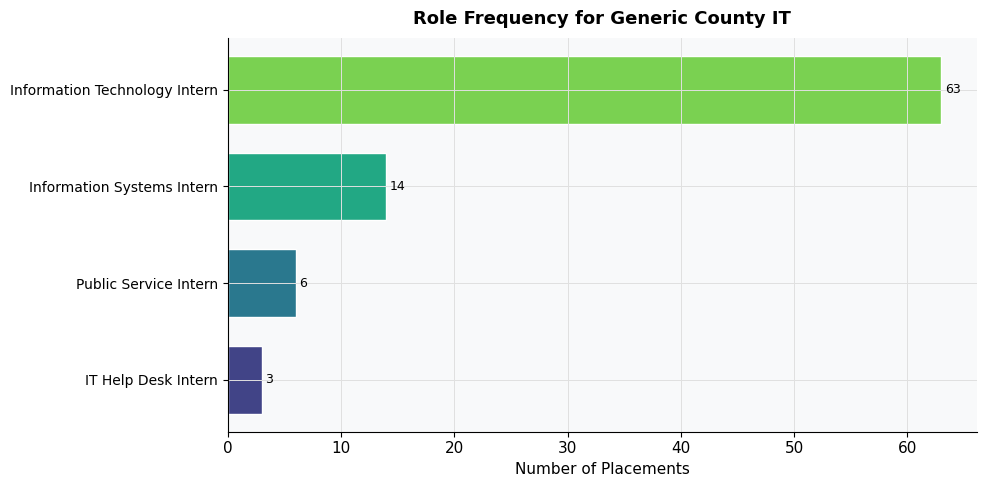


Detailed role counts for 'Generic County IT':
Title
Information Technology Intern    63
Information Systems Intern       14
Public Service Intern             6
IT Help Desk Intern               3


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter placements for 'Generic County IT'
gc_it_placements = placements[placements['Employer'] == 'Generic County IT'].copy()

# Count the frequency of each role
gc_it_role_counts = gc_it_placements['Title'].value_counts()


if not gc_it_role_counts.empty:
    fig, ax = plt.subplots(figsize=(10, max(5, len(gc_it_role_counts)*0.7)))
    colors = sns.color_palette('viridis', n_colors=len(gc_it_role_counts))

    # Sort roles for better visualization if there are many
    plot_data = gc_it_role_counts.sort_values(ascending=True)

    bars = ax.barh(plot_data.index, plot_data.values, color=colors, edgecolor='white', height=0.7)

    ax.set_xlabel('Number of Placements')
    ax.set_title('Role Frequency for Generic County IT', pad=10)
    ax.tick_params(axis='y', labelsize=10)

    for bar, val in zip(bars, plot_data.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nDetailed role counts for 'Generic County IT':")
    print(gc_it_role_counts.to_string())
else:
    print("No placements found for 'Generic County IT'.")

### 8.4 Role Frequency within 'Generic County Public Health'

This section visualizes the distribution and frequency of all roles offered specifically by 'Generic County Public Health'.

In [ ]:
LOW_COMPLETION_THRESHOLD = 50

# Filter employers from emp_sorted (which already includes quality score and placement counts)
# for those with a Planned Completion rate below the threshold
# and potentially a lower quality score (e.g., below median or a specific threshold)

high_risk_low_completion = emp_sorted[
    (emp_sorted['Planned Completion'] < LOW_COMPLETION_THRESHOLD) |
    (emp_sorted['quality_score'] < emp_sorted['quality_score'].median())
].copy()

# Sort by Planned Completion ascending to show the lowest ones first
high_risk_low_completion_sorted = high_risk_low_completion.sort_values(
    'Planned Completion', ascending=True
)

print(f"\nHigh-risk employers (Planned Completion < {LOW_COMPLETION_THRESHOLD}% or Quality Score < median) (n>={MIN_PLACEMENTS}):")
if not high_risk_low_completion_sorted.empty:
    cols = ['Planned Completion', 'Student Exit', 'Re-engagement', 'quality_score', 'total_placements']
    display(high_risk_low_completion_sorted[cols].round(1))
else:
    print("  No additional high-risk employers identified based on these criteria.")


High-risk employers (Planned Completion < 50% or Quality Score < median) (n>=5):


outcome,Planned Completion,Student Exit,Re-engagement,quality_score,total_placements
Employer,,,,,
Millio's Youth and Outreach Services,23.1,57.7,3.8,25.0,26
Somerset Academy,23.2,55.1,2.9,25.7,69
Tekgration LLC,30.0,45.0,5.0,32.5,20
Generic ISD - North,35.7,19.0,11.9,44.5,42
Generic County Justice Services,40.0,32.0,0.0,40.4,25
Southwest Voter Registration Education Project,42.9,16.7,14.3,49.3,42
Bario Aviation Services,44.4,18.5,11.1,48.9,27
SAMSAT,44.8,29.1,12.7,46.2,134
"Education Service Center, Region 20",47.6,33.3,9.5,45.7,21



Analyzing 'Student Exit' reasons for the top 3 high-risk employers: Millio's Youth and Outreach Services, Somerset Academy, Tekgration LLC

--- Millio's Youth and Outreach Services - Student Exit Reasons ---
Reason for ended assignment
Did Not Complete Employer Pre-screen    6
Voluntary Withdrawal                    4
Student Ended Assignment                3
Job Abandonment                         2




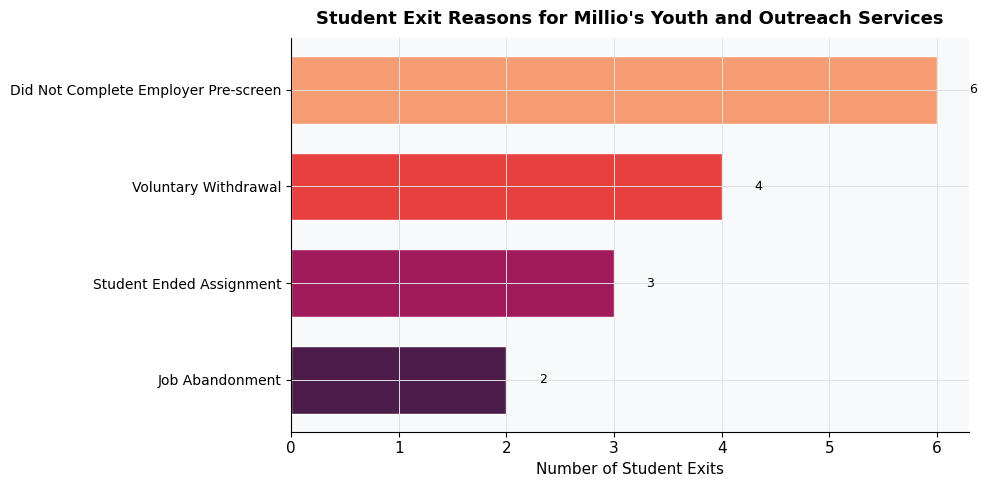

--- Somerset Academy - Student Exit Reasons ---
Reason for ended assignment
Student Ended Assignment                12
Job Abandonment                         11
Did Not Complete Employer Pre-screen     8
Voluntary Withdrawal                     7




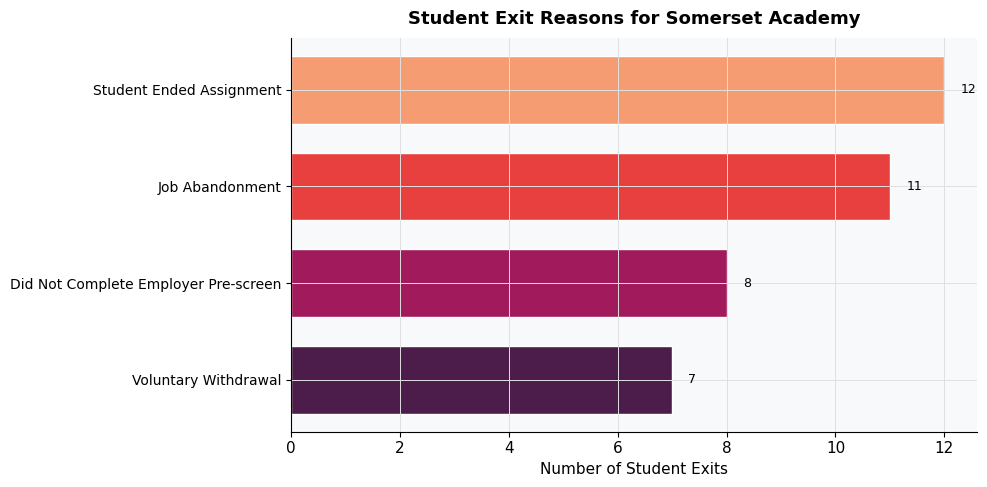

--- Tekgration LLC - Student Exit Reasons ---
Reason for ended assignment
Job Abandonment                         3
Student Ended Assignment                3
Voluntary Withdrawal                    2
Did Not Complete Employer Pre-screen    1




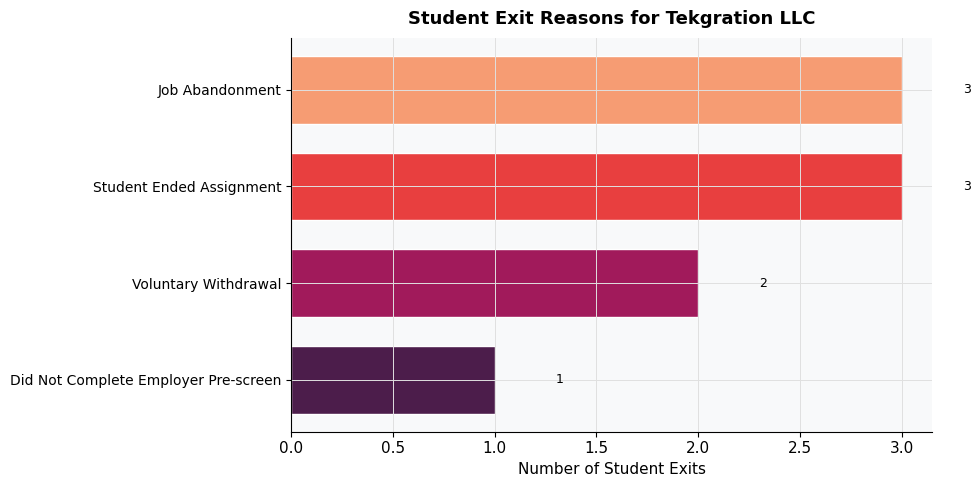

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 3 high-risk employers by lowest Planned Completion rate
top3_high_risk_employers = high_risk_low_completion_sorted.head(3).index.tolist()

print(f"\nAnalyzing 'Student Exit' reasons for the top 3 high-risk employers: {', '.join(top3_high_risk_employers)}\n")

for employer_name in top3_high_risk_employers:
    # Filter data for the specific employer and 'Student Exit' outcome
    employer_exit_reasons = ended[
        (ended['Employer'] == employer_name) &
        (ended['outcome'] == 'Student Exit')
    ]['Reason for ended assignment'].value_counts()

    if not employer_exit_reasons.empty:
        print(f"--- {employer_name} - Student Exit Reasons ---")
        print(employer_exit_reasons.to_string())
        print("\n")

        # Plotting the reasons for each employer
        fig, ax = plt.subplots(figsize=(10, max(5, len(employer_exit_reasons) * 0.7)))
        colors = sns.color_palette('rocket', n_colors=len(employer_exit_reasons))

        # Sort reasons for better visualization
        plot_data = employer_exit_reasons.sort_values(ascending=True)

        bars = ax.barh(plot_data.index, plot_data.values, color=colors, edgecolor='white', height=0.7)

        ax.set_xlabel('Number of Student Exits')
        ax.set_title(f"Student Exit Reasons for {employer_name}", pad=10)
        ax.tick_params(axis='y', labelsize=10)

        for bar, val in zip(bars, plot_data.values):
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

        plt.tight_layout()
        plt.show()
    else:
        print(f"No 'Student Exit' records found for {employer_name}.")

### Analyzing 'Tenure Days' vs. 'Exit Outcomes' for High-Risk Employers

In [ ]:
import scipy.stats as stats

# Get the list of top 3 high-risk employers (from previous analysis)
top3_high_risk_employers = high_risk_low_completion_sorted.head(3).index.tolist()

# Filter the 'ended' DataFrame for these high-risk employers
high_risk_ended = ended[ended['Employer'].isin(top3_high_risk_employers)].copy()

print(f"\nAnalysis of tenure days and outcomes for high-risk employers: {', '.join(top3_high_risk_employers)}\n")

# 1. Average 'tenure_days' for each outcome type
tenure_by_outcome = high_risk_ended.groupby('outcome')['tenure_days'].agg(['mean', 'median', 'count'])
print("Average and Median Tenure (Days) by Outcome for High-Risk Employers:")
display(tenure_by_outcome.round(1))

# 2. Point-biserial correlation between 'tenure_days' and 'Student Exit'
# Create a binary variable for 'Student Exit'
high_risk_ended['is_student_exit'] = (high_risk_ended['outcome'] == 'Student Exit').astype(int)

# Filter out NaN tenure_days for correlation calculation
corr_df = high_risk_ended.dropna(subset=['tenure_days', 'is_student_exit'])

if len(corr_df) > 1:
    correlation, p_value = stats.pointbiserialr(corr_df['is_student_exit'], corr_df['tenure_days'])
    print(f"\nPoint-biserial correlation between 'is_student_exit' and 'tenure_days': {correlation:.3f}")
    print(f"P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("The correlation is statistically significant (at alpha = 0.05).")
    else:
        print("The correlation is not statistically significant (at alpha = 0.05).")
    print("A negative correlation would suggest that 'Student Exit' is associated with shorter tenures.")
else:
    print("\nNot enough data to calculate point-biserial correlation for high-risk employers.")



Analysis of tenure days and outcomes for high-risk employers: Millio's Youth and Outreach Services, Somerset Academy, Tekgration LLC

Average and Median Tenure (Days) by Outcome for High-Risk Employers:


,mean,median,count
outcome,,,
Administrative Exit,51.0,41.0,3
Employer Exit,97.5,97.0,18
Planned Completion,173.8,179.5,28
Re-engagement,131.0,110.5,4
Student Exit,49.4,32.5,62



Point-biserial correlation between 'is_student_exit' and 'tenure_days': -0.579
P-value: 0.000
The correlation is statistically significant (at alpha = 0.05).
A negative correlation would suggest that 'Student Exit' is associated with shorter tenures.


#### Interpretation of Results

- **Average Tenure by Outcome:** This table shows the typical duration of placements for each outcome category for the identified high-risk employers. For instance, 'Student Exit' outcomes are likely associated with shorter `tenure_days` compared to 'Planned Completion'.

- **Point-Biserial Correlation:** The point-biserial correlation coefficient quantifies the relationship between the binary variable ('is_student_exit') and the continuous variable ('tenure_days'). A negative correlation suggests that student exits tend to occur earlier (shorter tenure). The p-value indicates the statistical significance of this correlation.

Total IT-related placements: 447
Total Non-IT placements: 776

IT-related placements constitute 36.5% of all placements.
Non-IT placements constitute 63.5% of all placements.


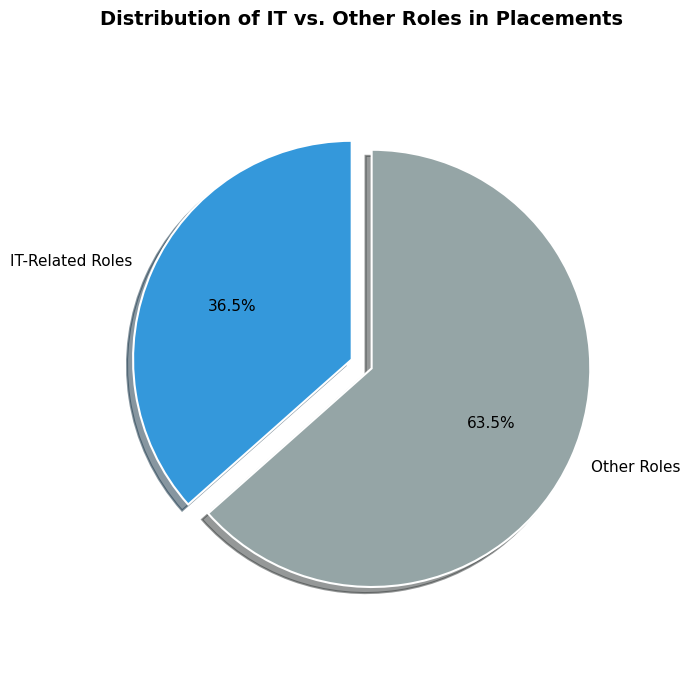

In [ ]:
it_keywords = ['IT', 'Information Technology', 'Information Systems']

# Identify IT-related placements
it_placements = placements[
    placements['Title'].fillna('').str.contains('|'.join(it_keywords), case=False, regex=True)
].copy()

# Identify non-IT related placements
non_it_placements = placements[
    ~placements['Title'].fillna('').str.contains('|'.join(it_keywords), case=False, regex=True)
].copy()

print(f"Total IT-related placements: {len(it_placements)}")
print(f"Total Non-IT placements: {len(non_it_placements)}")

# Calculate overall distribution
total_placements = len(placements)
it_pct = len(it_placements) / total_placements * 100
non_it_pct = len(non_it_placements) / total_placements * 100

print(f"\nIT-related placements constitute {it_pct:.1f}% of all placements.")
print(f"Non-IT placements constitute {non_it_pct:.1f}% of all placements.")

# Plotting the distribution of IT vs Non-IT roles
fig, ax = plt.subplots(figsize=(7, 7))

labels = ['IT-Related Roles', 'Other Roles']
sizes = [it_pct, non_it_pct]
colors = ['#3498DB', '#95A5A6']
explode = (0.1, 0)  # Explode the 1st slice (IT-Related Roles)

ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
       shadow=True, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax.set_title('Distribution of IT vs. Other Roles in Placements', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

### Top IT Roles and their Employers

Top 10 IT-related employer-role pairings by volume:


,,0
Employer,Title,
Generic ISD,Information Technology Intern,126
Generic County IT,Information Technology Intern,63
Somerset Academy,IT Help Desk Intern,63
American Red Cross,Non-Profit Management Intern,33
Millio's Youth and Outreach Services,Non-Profit Management Intern,26
Generic ISD,IT Help Desk Intern,23
Tekgration LLC,IT Software Development Intern,15
Generic County IT,Information Systems Intern,14
Generic ISD - North,IT Help Desk Intern,13


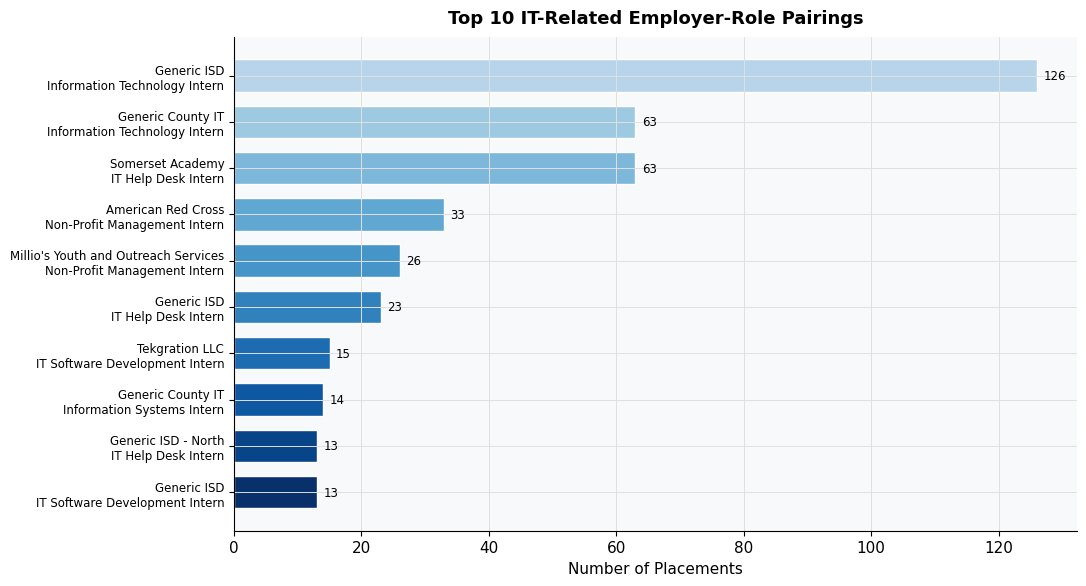

In [ ]:
# Top 10 IT-related employer-role pairings
it_pairing_counts = it_placements.groupby(['Employer', 'Title']).size().sort_values(ascending=False)
top_10_it_pairings = it_pairing_counts.head(10)

print("Top 10 IT-related employer-role pairings by volume:")
display(top_10_it_pairings)

# Visualize Top IT Roles
if not top_10_it_pairings.empty:
    fig, ax = plt.subplots(figsize=(11, max(6, len(top_10_it_pairings) * 0.5)))
    top10_it_labels = [f"{emp}\n{role}" for emp, role in top_10_it_pairings.index]
    colors_it_pairing = plt.cm.Blues(np.linspace(0.3, 1, len(top_10_it_pairings)))

    bars = ax.barh(range(len(top_10_it_pairings)), top_10_it_pairings.values[::-1],
                   color=colors_it_pairing[::-1], edgecolor='white', height=0.7)
    ax.set_yticks(range(len(top_10_it_pairings)))
    ax.set_yticklabels(top10_it_labels[::-1], fontsize=8.5)
    ax.set_xlabel('Number of Placements')
    ax.set_title('Top 10 IT-Related Employer-Role Pairings', pad=10)

    for i, val in enumerate(top_10_it_pairings.values[::-1]):
        ax.text(val + 1, i, str(val), va='center', fontsize=8.5)

    plt.tight_layout()
    plt.show()
else:
    print("No IT-related employer-role pairings found.")

### Top Non-IT Roles and their Employers

Top 10 Non-IT employer-role pairings by volume:


,,0
Employer,Title,
Altus Hospice,Healthcare Intern,150
SAMSAT,STEM Intern,101
Accenture Federal Services,Apprentice in Training,72
"Quantum Institute Fellows, Inc",Quantum Computing Research Intern,52
San Pedro Playhouse,Production Intern,48
Southwest Voter Registration Education Project,Public Service Intern,32
Generic ISD - North,Education Intern,29
Bario Aviation Services,Aviation Intern,27
SAMSAT,Esports Intern,26


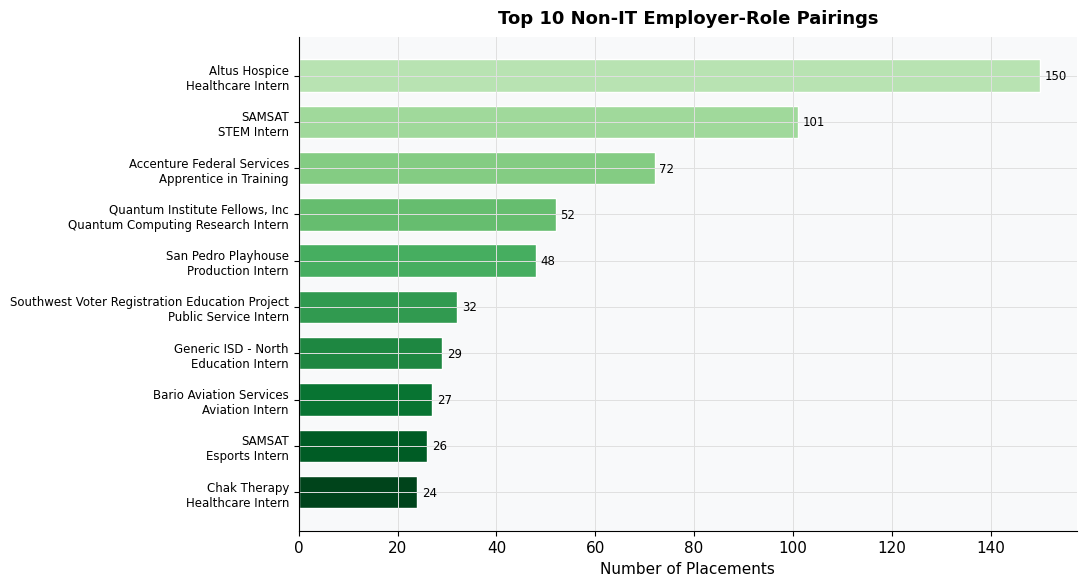

In [ ]:
# Top 10 Non-IT employer-role pairings
non_it_pairing_counts = non_it_placements.groupby(['Employer', 'Title']).size().sort_values(ascending=False)
top_10_non_it_pairings = non_it_pairing_counts.head(10)

print("Top 10 Non-IT employer-role pairings by volume:")
display(top_10_non_it_pairings)

# Visualize Top Non-IT Roles
if not top_10_non_it_pairings.empty:
    fig, ax = plt.subplots(figsize=(11, max(6, len(top_10_non_it_pairings) * 0.5)))
    top10_non_it_labels = [f"{emp}\n{role}" for emp, role in top_10_non_it_pairings.index]
    colors_non_it_pairing = plt.cm.Greens(np.linspace(0.3, 1, len(top_10_non_it_pairings)))

    bars = ax.barh(range(len(top_10_non_it_pairings)), top_10_non_it_pairings.values[::-1],
                   color=colors_non_it_pairing[::-1], edgecolor='white', height=0.7)
    ax.set_yticks(range(len(top_10_non_it_pairings)))
    ax.set_yticklabels(top10_non_it_labels[::-1], fontsize=8.5)
    ax.set_xlabel('Number of Placements')
    ax.set_title('Top 10 Non-IT Employer-Role Pairings', pad=10)

    for i, val in enumerate(top_10_non_it_pairings.values[::-1]):
        ax.text(val + 1, i, str(val), va='center', fontsize=8.5)

    plt.tight_layout()
    plt.show()
else:
    print("No Non-IT employer-role pairings found.")

In [ ]:
import scipy.stats as stats

# Calculate Pearson correlation between Quality Score and Planned Completion
correlation_pc, p_value_pc = stats.pearsonr(emp_q['quality_score'], emp_q['Planned Completion'])

# Calculate Pearson correlation between Quality Score and Student Exit
correlation_se, p_value_se = stats.pearsonr(emp_q['quality_score'], emp_q['Student Exit'])

print(f"Pearson correlation between Quality Score and Planned Completion: {correlation_pc:.3f} (p={p_value_pc:.3f})")
print(f"Pearson correlation between Quality Score and Student Exit:    {correlation_se:.3f} (p={p_value_se:.3f})")

print("\nA positive correlation with Planned Completion suggests higher quality scores are associated with better retention.")
print("A negative correlation with Student Exit suggests higher quality scores are associated with lower exit rates.")

Pearson correlation between Quality Score and Planned Completion: 0.968 (p=0.000)
Pearson correlation between Quality Score and Student Exit:    -0.935 (p=0.000)

A positive correlation with Planned Completion suggests higher quality scores are associated with better retention.
A negative correlation with Student Exit suggests higher quality scores are associated with lower exit rates.


In [ ]:
high_risk_employers_list = high_risk_low_completion_sorted.index.tolist()

# Separate high-risk and low-risk employers based on the `high_risk_low_completion_sorted` list
high_risk_costs = cost_df[cost_df['Employer'].isin(high_risk_employers_list)]
low_risk_costs = cost_df[~cost_df['Employer'].isin(high_risk_employers_list)]

# Calculate average cost per completion for each group
avg_high_risk_cost = high_risk_costs['cost_per_completion'].mean()
avg_low_risk_cost = low_risk_costs['cost_per_completion'].mean()

print(f"Average Cost per Completion for High-Risk Employers: ${avg_high_risk_cost:,.0f}")
print(f"Average Cost per Completion for Low-Risk Employers:  ${avg_low_risk_cost:,.0f}")

# Create a DataFrame for better display
comparison_costs = pd.DataFrame({
    'Employer Group': ['High-Risk Employers', 'Low-Risk Employers'],
    'Average Cost per Completion': [avg_high_risk_cost, avg_low_risk_cost]
})

display(comparison_costs.round(0))

Average Cost per Completion for High-Risk Employers: $12,746
Average Cost per Completion for Low-Risk Employers:  $7,464


,Employer Group,Average Cost per Completion
0,High-Risk Employers,12746.0
1,Low-Risk Employers,7464.0


In [ ]:
isd_employers = [emp for emp in ended['Employer'].unique() if 'ISD' in emp]

# Get quality scores for ISD employers
isd_quality = emp_q[emp_q.index.isin(isd_employers)].copy()

# Get cost per completion for ISD employers
isd_cost = cost_df[cost_df['Employer'].isin(isd_employers)].copy()

# Merge the dataframes for a comprehensive summary
isd_summary = isd_quality.merge(
    isd_cost[['Employer', 'cost_per_completion']],
    left_index=True,
    right_on='Employer',
    how='left'
)

# Select and order relevant columns for display
display_cols = [
    'Employer',
    'quality_score',
    'Planned Completion',
    'Re-engagement',
    'Student Exit',
    'Employer Exit',
    'Administrative Exit',
    'total_placements',
    'cost_per_completion'
]

isd_summary = isd_summary[display_cols].round(1)

print("\nPerformance Summary for ISD-Related Employers:")
display(isd_summary)


Performance Summary for ISD-Related Employers:


,Employer,quality_score,Planned Completion,Re-engagement,Student Exit,Employer Exit,Administrative Exit,total_placements,cost_per_completion
9,Generic ISD,49.1,50.0,10.0,26.3,8.4,5.3,190,10081.2
10,Generic ISD - North,44.5,35.7,11.9,19.0,21.4,11.9,42,13674.4


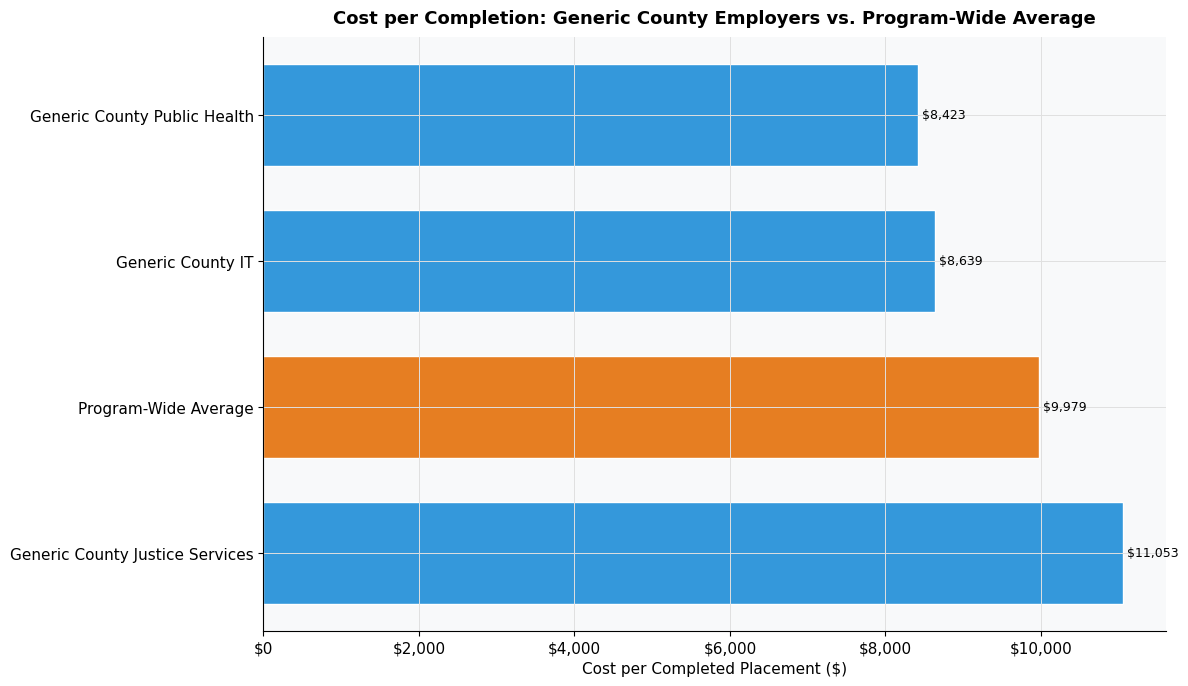


Detailed Cost per Completion:


,Employer,Cost per Completion
2,Generic County Justice Services,11053.0
3,Program-Wide Average,9979.0
1,Generic County IT,8639.0
0,Generic County Public Health,8423.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_data = pd.DataFrame({
    'Employer': gc_employers_cost['Employer'].tolist() + ['Program-Wide Average'],
    'Cost per Completion': gc_employers_cost['cost_per_completion'].tolist() + [overall_avg_cost_per_completion]
})

# Sort by cost per completion for better visualization
plot_data_sorted = plot_data.sort_values('Cost per Completion', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))

# Define colors: highlight 'Program-Wide Average' differently
colors = ['#E67E22' if 'Program-Wide Average' in emp else '#3498DB' for emp in plot_data_sorted['Employer']]

bars = ax.barh(plot_data_sorted['Employer'], plot_data_sorted['Cost per Completion'], color=colors, edgecolor='white', height=0.7)

ax.set_xlabel('Cost per Completed Placement ($)')
ax.set_title('Cost per Completion: Generic County Employers vs. Program-Wide Average', pad=10)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for bar, val in zip(bars, plot_data_sorted['Cost per Completion']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nDetailed Cost per Completion:")
display(plot_data.round(0).sort_values('Cost per Completion', ascending=False))

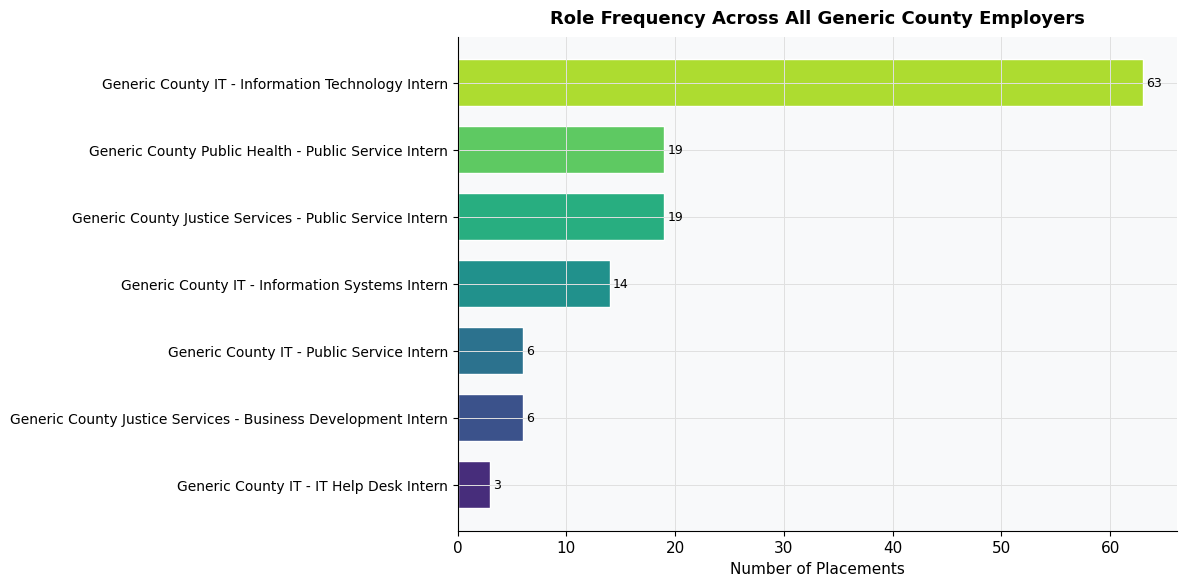


Detailed role counts across all Generic County employers:
Employer                         Title                        
Generic County IT                Information Technology Intern    63
Generic County Justice Services  Public Service Intern            19
Generic County Public Health     Public Service Intern            19
Generic County IT                Information Systems Intern       14
Generic County Justice Services  Business Development Intern       6
Generic County IT                Public Service Intern             6
                                 IT Help Desk Intern               3


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# gc_pairing_counts was already calculated in cell '6dca5a91'
# Employer-role pairing concentration — the real risk metric
# gc_pairing_counts = placements_gc.groupby(['Employer','Title']).size().sort_values(ascending=False)

if not gc_pairing_counts.empty:
    # Prepare data for plotting
    plot_data = gc_pairing_counts.reset_index()
    # Create a combined label for better readability on the y-axis
    plot_data['Employer_Title'] = plot_data['Employer'] + ' - ' + plot_data['Title']
    # Rename the count column for clarity
    plot_data.rename(columns={0: 'Placements'}, inplace=True)

    # Sort for better visualization, e.g., by placement count ascending
    plot_data_sorted = plot_data.sort_values(by='Placements', ascending=True)

    fig, ax = plt.subplots(figsize=(12, max(6, len(plot_data_sorted) * 0.5)))

    # Use a color palette that distinguishes different employers if possible
    # For simplicity, using a single palette here, but could customize further
    colors = sns.color_palette('viridis', n_colors=len(plot_data_sorted))

    bars = ax.barh(plot_data_sorted['Employer_Title'], plot_data_sorted['Placements'],
                   color=colors, edgecolor='white', height=0.7)

    ax.set_xlabel('Number of Placements')
    ax.set_title('Role Frequency Across All Generic County Employers', pad=10)
    ax.tick_params(axis='y', labelsize=10)

    for bar, val in zip(bars, plot_data_sorted['Placements']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nDetailed role counts across all Generic County employers:")
    print(gc_pairing_counts.to_string())
else:
    print("No employer-role pairings found for Generic County.")

---
## Summary

| Item | Value |
|---|---|
| Program | Workforce Bridge Program (WBP) |
| Pay rate | $18.00/hour, flat across all roles |
| Hours per week | Avg 17, max 20 |
| Placement length | Up to 9 months |
| Coverage | Spring 2022 – Summer 2026 |
| Completion rate | *see output above* |
| Early exits (≤60 days) | *see output above* |
| At-risk employer partners | *see output above* |
| Concentration index (HHI) | *see output above* |
| Cost per completion (program-wide) | *see output above* |

### Key Takeaways

1. **Most attrition is early** the highest-leverage intervention window is the first 60 days.
2. **Employer quality is measurable and unevenly distributed** a scoring model surfaces both strong and at-risk partners.
3. **Cost-per-completion reveals efficiency gaps invisible in completion-rate-only reporting** some partners cost significantly more per success.
4. **Volume has a seasonal rhythm** staffing should plan around it, not assume flat demand.
5. **The pipeline carries real concentration risk** a small number of employer-role pairings account for a large share of placements.

---
*All student identifiers anonymized. Employer and campus names anonymized
where identifying. Institution not disclosed. Independent portfolio project.*
